In [ ]:
# ── Global paths ──────────────────────────────────────────────────────────────
SWEAT_0 = "../20260404-experiment/sweat.csv"   
SWEAT_1 = "../20260405-experiment/sweat.csv"   # Reference — clean wiring
SWEAT_2 = "../20260424-experiment/sweat.csv"
SWEAT_3 = "../20260426-experiment/sweat.csv"
SWEAT_4 = "../20260427-experiment/sweat_1.csv"
SWEAT_5 = "../20260427-experiment/sweat_2.csv"
SWEAT_6 = "../20260429-experiment/sweat_1.csv"
SWEAT_7 = "../20260429-experiment/sweat_2.csv"

BLOOD_0 = "../20260406-experiment/1.5_blood.csv"
BLOOD_1 = "../20260406-experiment/1.5_blood_2.csv"
BLOOD_2 = "../20260421-experiment/1.5_blood.csv"
BLOOD_3 = "../20260421-experiment/1.5_blood_2.csv"
BLOOD_4 = "../20260422-experiment/1.5_blood.csv"
BLOOD_5 = "../20260422-experiment/1.5_blood_2.csv"
BLOOD_6 = "../20260424-experiment/1.5_blood.csv"
BLOOD_7 = "../20260424-experiment/1.5_blood_2.csv"
BLOOD_8 = "../20260426-experiment/1.5_blood.csv"
BLOOD_9 = "../20260426-experiment/1.5_blood_2.csv"

BLOOD_TEST_0 = "../20260426-experiment/1.5_blood.csv"
SWEAT_TEST_0 = ""

MEMS = ["voc", "nh3", "hcho"]

# Smoothing params
ROLLING_WINDOW = 20   
SG_WINDOW      = 31   # Savitzky-Golay window (must be odd)
SG_POLY        = 3    # Savitzky-Golay polynomial order

# SWEAT_0 defect: NH3 zero runs (rows where NH3 = 0.0 V)
SWEAT_0_DEFECT_ZERO_RUNS = [(3912, 3983), (4012, 4036)]  # (start_row, end_row)


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

def load(path, t_min=0, t_max=None):
    df = pd.read_csv(path, parse_dates=["wall_time"])
    df["elapsed_s"] = (df["wall_time"] - df["wall_time"].iloc[0]).dt.total_seconds()
    for col in MEMS:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    df = df[df["elapsed_s"] >= t_min]
    if t_max is not None:
        df = df[df["elapsed_s"] < t_max]
    return df.reset_index(drop=True)

SWEAT_1_RESET_S = 4000   # Reset event — recording restarted, sensor stayed powered

sweat_0  = load(SWEAT_0, t_max=4000)
sweat_1  = load(SWEAT_1)
sweat_1a = load(SWEAT_1, t_max=SWEAT_1_RESET_S)
sweat_1b = load(SWEAT_1, t_min=SWEAT_1_RESET_S)
sweat_1b = sweat_1b.assign(
    elapsed_s=sweat_1b["elapsed_s"] - sweat_1b["elapsed_s"].iloc[0]
)
sweat_2  = load(SWEAT_2)
sweat_3  = load(SWEAT_3)
sweat_4  = load(SWEAT_4)
sweat_5  = load(SWEAT_5)
sweat_6  = load(SWEAT_6)
sweat_7  = load(SWEAT_7)

blood_0  = load(BLOOD_0)
blood_1  = load(BLOOD_1, t_min=1750)
blood_2  = load(BLOOD_2)
blood_3  = load(BLOOD_3)
blood_4  = load(BLOOD_4)
blood_5  = load(BLOOD_5)
blood_6  = load(BLOOD_6)
blood_7  = load(BLOOD_7)
blood_8  = load(BLOOD_8)
blood_9  = load(BLOOD_9)

print(f"{'Dataset':<12}  {'Rows':>6}  {'Duration':>10}")
print("-" * 34)
for name, df in [
    ("sweat_1a",  sweat_1a), ("sweat_1b", sweat_1b),
    ("sweat_2",   sweat_2),  ("sweat_3",  sweat_3),
    ("sweat_4",   sweat_4),  ("sweat_5",  sweat_5),
    ("sweat_6",   sweat_6),  ("sweat_7",  sweat_7),
    ("blood_0",   blood_0),  ("blood_1",  blood_1),
    ("blood_2",   blood_2),  ("blood_3",  blood_3),
    ("blood_4",   blood_4),  ("blood_5",  blood_5),
    ("blood_6",   blood_6),  ("blood_7",  blood_7),
    ("blood_8",   blood_8),  ("blood_9",  blood_9),
]:
    print(f"{name:<12}  {len(df):>6}  {df['elapsed_s'].iloc[-1]:>8.0f} s")


Dataset         Rows    Duration
----------------------------------
sweat_1a        3909      4000 s
sweat_1b        2390      2446 s
sweat_2         5393      5521 s
sweat_3         5106      5227 s
sweat_4         4930      5042 s
sweat_5         2723      2786 s
sweat_6         5903      6133 s
sweat_7         3543      3659 s
blood_0         3666      3753 s
blood_1         1908      3703 s
blood_2         2882      2987 s
blood_3         3324      3484 s
blood_4         2357      2473 s
blood_5         3598      3746 s
blood_6         3872      3963 s
blood_7         3486      3568 s
blood_8         3705      3791 s
blood_9         4093      4190 s


## SWEAT_0 Defect Investigation

**Problem:** The NH3 sensor wire was miswired to the VOC ADC pin from the beginning of the session — not during recording.

**Effect on NH3:** Pin 34 (NH3) was floating/unconnected → reads `0.0 V` for large blocks of the session.

**Effect on VOC:** The NH3 wire loading pin 35 (VOC) might suppress the VOC readings.

**Conclusion:** SWEAT_0 VOC and NH3 channels are both unreliable and should not be used for model training.


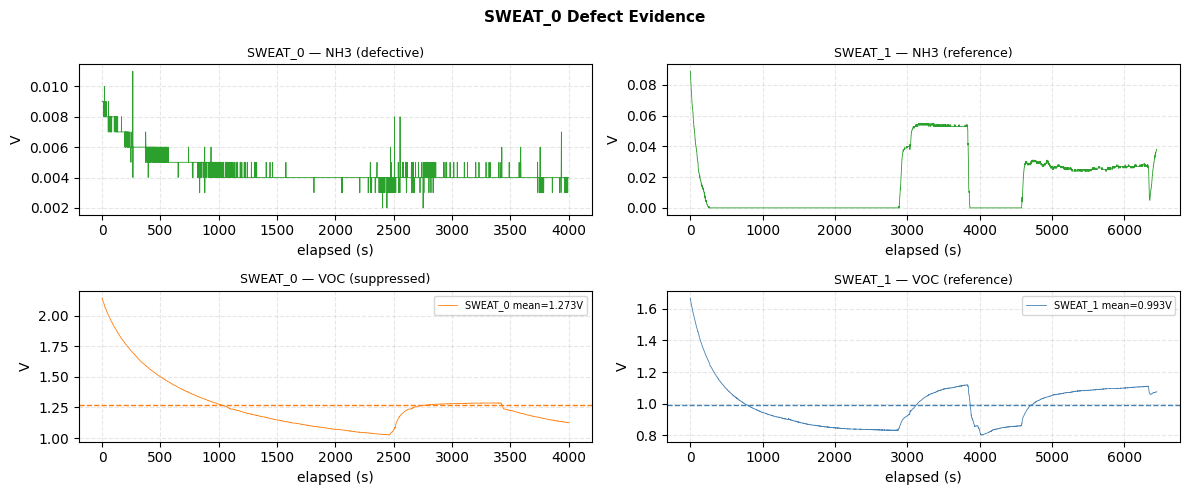

NH3 zeros in SWEAT_0: 0/3874 (0.0%)
VOC mean — SWEAT_0: 1.273 V   SWEAT_1: 0.993 V  (diff: -0.280 V)


In [3]:
fig, axes = plt.subplots(2, 2, figsize=(12, 5))
fig.suptitle("SWEAT_0 Defect Evidence", fontsize=11, fontweight="bold")

# Detect zero-run time spans directly from the trimmed dataframe
def zero_time_spans(df, col):
    is_zero = (df[col] == 0.0)
    spans = []
    in_run = False
    for i, val in enumerate(is_zero):
        if val and not in_run:
            in_run = True
            t_start = df["elapsed_s"].iloc[i]
        elif not val and in_run:
            in_run = False
            spans.append((t_start, df["elapsed_s"].iloc[i - 1]))
    if in_run:
        spans.append((t_start, df["elapsed_s"].iloc[-1]))
    return spans

# NH3: stuck-at-zero blocks (defective)
ax = axes[0, 0]
ax.plot(sweat_0["elapsed_s"], sweat_0["nh3"], color="tab:green", linewidth=0.6)
for t0, t1 in zero_time_spans(sweat_0, "nh3"):
    ax.axvspan(t0, t1, color="red", alpha=0.2, label="stuck at 0 V")
ax.set_title("SWEAT_0 — NH3 (defective)", fontsize=9)
ax.set_ylabel("V"); ax.set_xlabel("elapsed (s)")
ax.grid(True, alpha=0.3, linestyle="--")
handles, labels = ax.get_legend_handles_labels()
if handles:
    ax.legend(handles[:1], labels[:1], fontsize=7)

# NH3 reference (full signal)
ax = axes[0, 1]
ax.plot(sweat_1["elapsed_s"], sweat_1["nh3"], color="tab:green", linewidth=0.6)
ax.set_title("SWEAT_1 — NH3 (reference)", fontsize=9)
ax.set_ylabel("V"); ax.set_xlabel("elapsed (s)")
ax.grid(True, alpha=0.3, linestyle="--")

# VOC defective
ax = axes[1, 0]
ax.plot(sweat_0["elapsed_s"], sweat_0["voc"], color="tab:orange", linewidth=0.6, label=f"SWEAT_0 mean={sweat_0['voc'].mean():.3f}V")
ax.axhline(sweat_0["voc"].mean(), color="tab:orange", linestyle="--", linewidth=1)
ax.set_title("SWEAT_0 — VOC (suppressed)", fontsize=9)
ax.set_ylabel("V"); ax.set_xlabel("elapsed (s)")
ax.legend(fontsize=7); ax.grid(True, alpha=0.3, linestyle="--")

# VOC reference
ax = axes[1, 1]
ax.plot(sweat_1["elapsed_s"], sweat_1["voc"], color="steelblue", linewidth=0.6, label=f"SWEAT_1 mean={sweat_1['voc'].mean():.3f}V")
ax.axhline(sweat_1["voc"].mean(), color="steelblue", linestyle="--", linewidth=1)
ax.set_title("SWEAT_1 — VOC (reference)", fontsize=9)
ax.set_ylabel("V"); ax.set_xlabel("elapsed (s)")
ax.legend(fontsize=7); ax.grid(True, alpha=0.3, linestyle="--")

plt.tight_layout()
plt.show()

nh3_zeros = (sweat_0["nh3"] == 0.0).sum()
print(f"NH3 zeros in SWEAT_0: {nh3_zeros}/{len(sweat_0)} ({100*nh3_zeros/len(sweat_0):.1f}%)")
print(f"VOC mean — SWEAT_0: {sweat_0['voc'].mean():.3f} V   SWEAT_1: {sweat_1['voc'].mean():.3f} V  (diff: {sweat_1['voc'].mean()-sweat_0['voc'].mean():.3f} V)")


## Initial Visualization

Raw signal with rolling average and Savitzky-Golay smoothing overlaid.
SWEAT_0 is included for completeness but its VOC/NH3 channels are defective (see above).


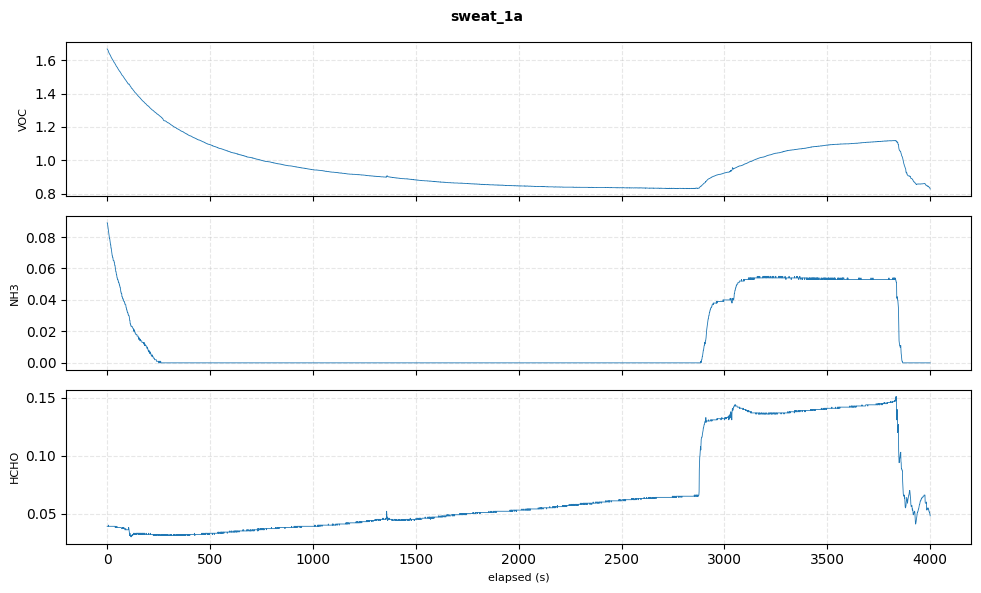

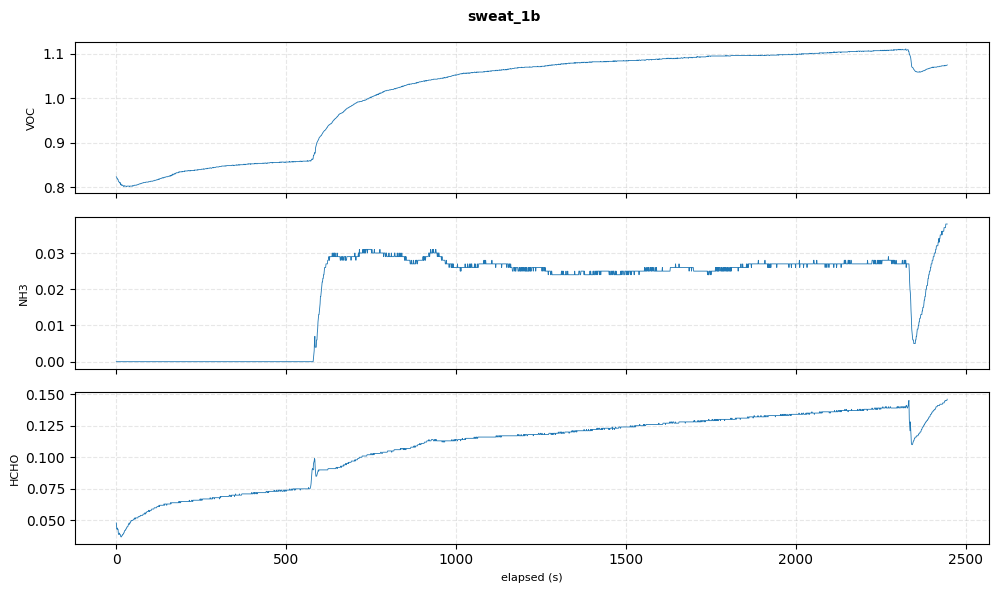

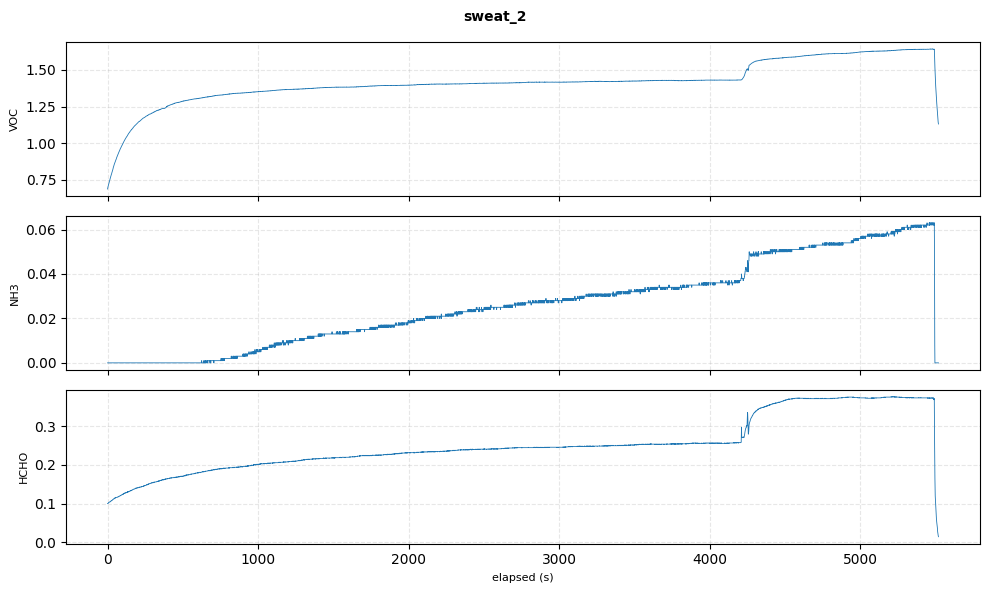

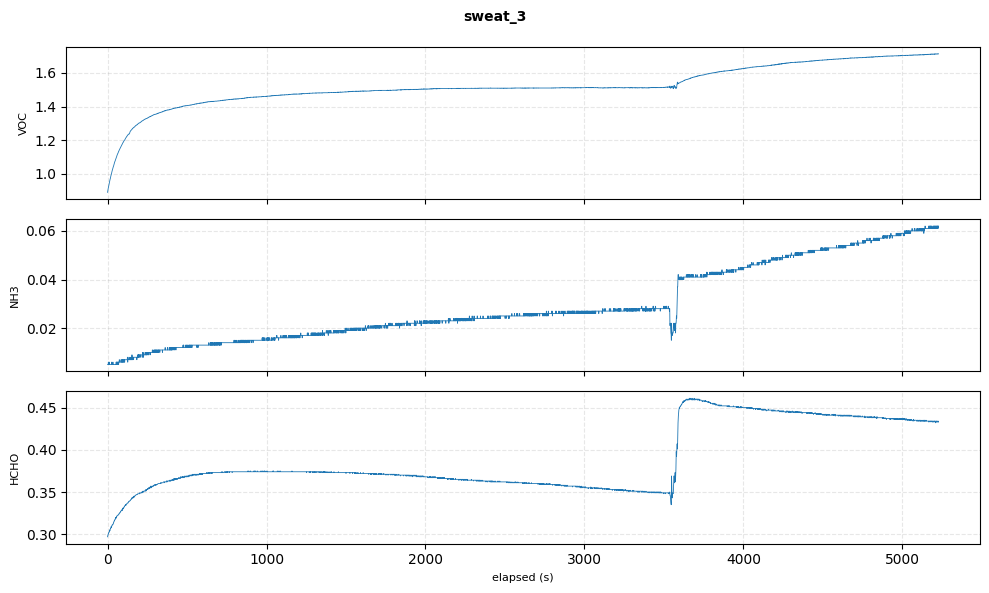

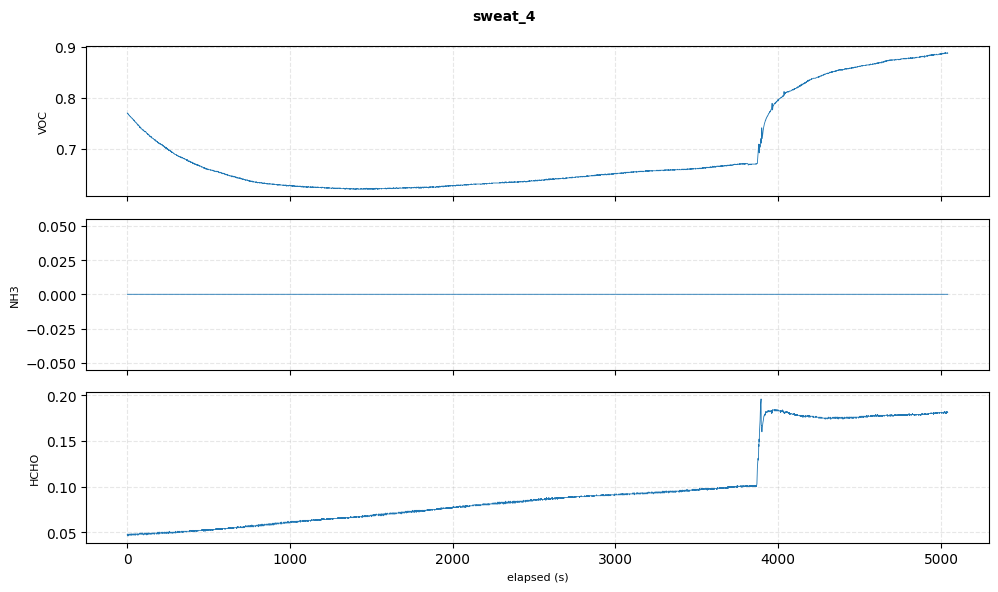

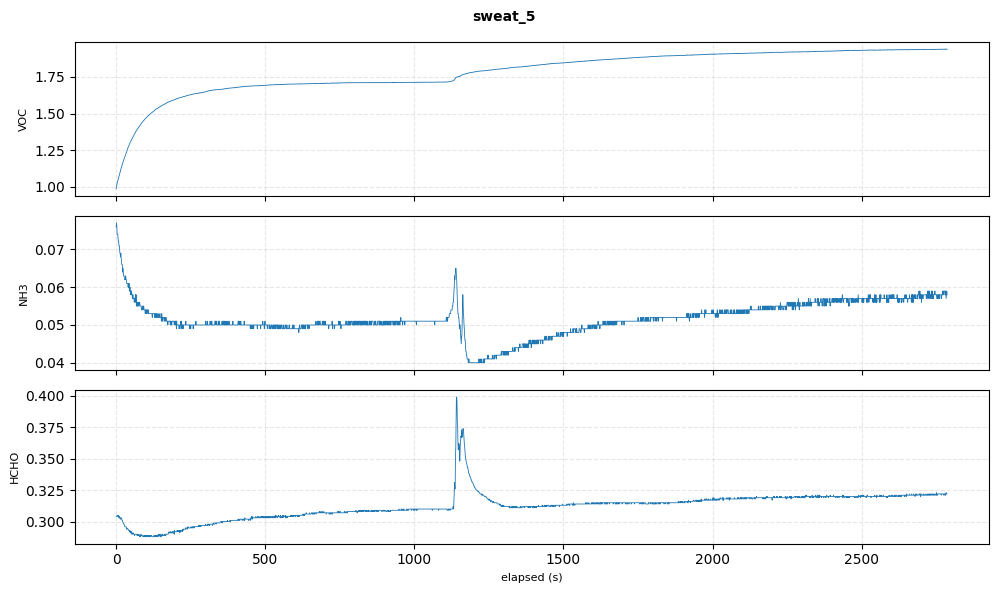

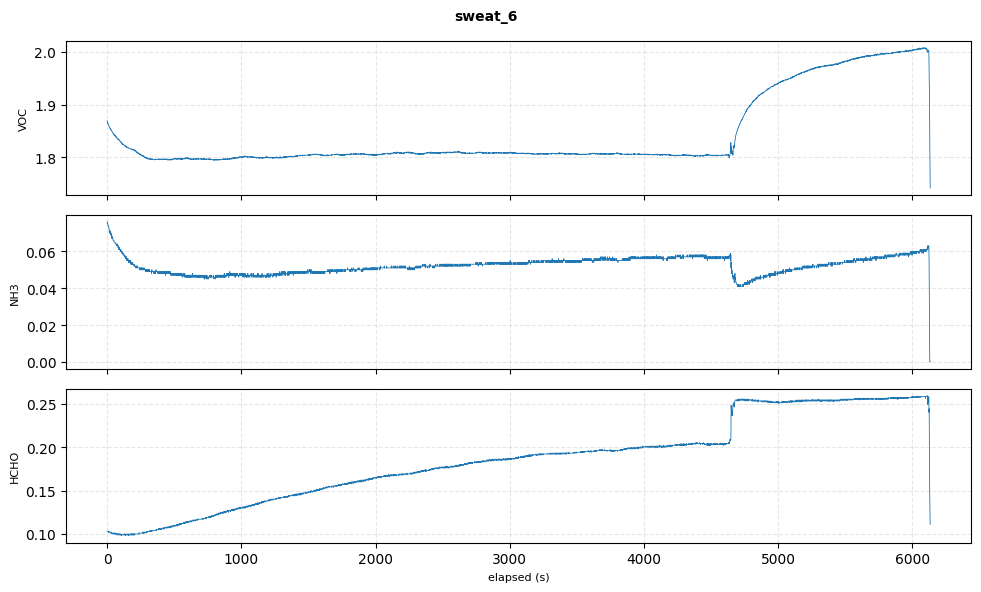

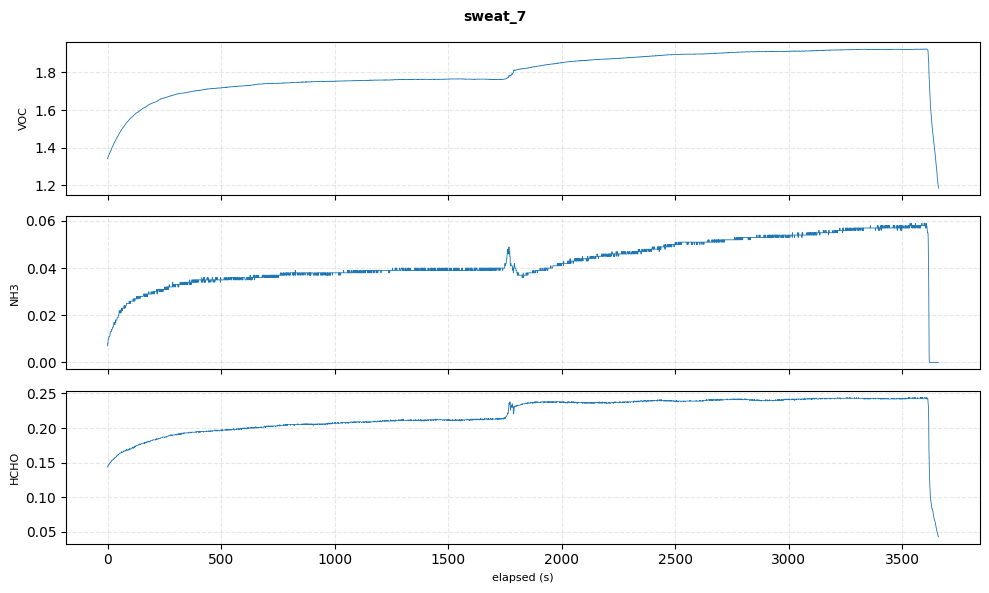

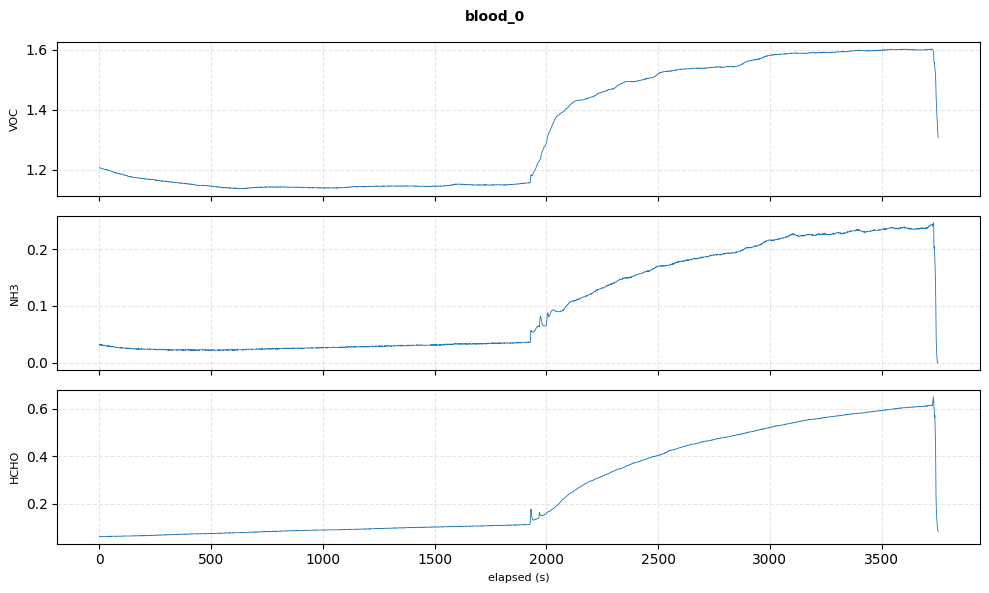

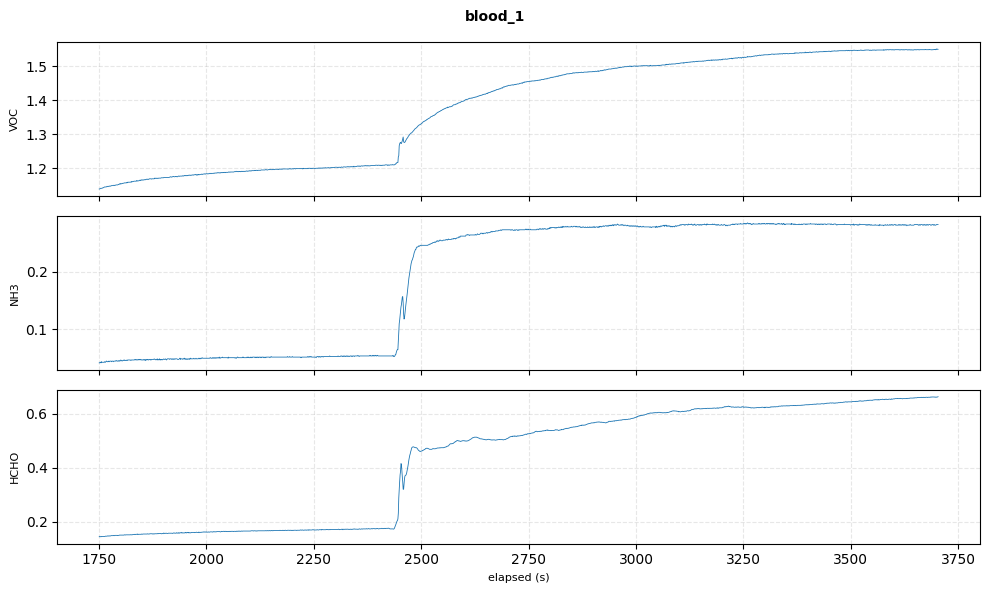

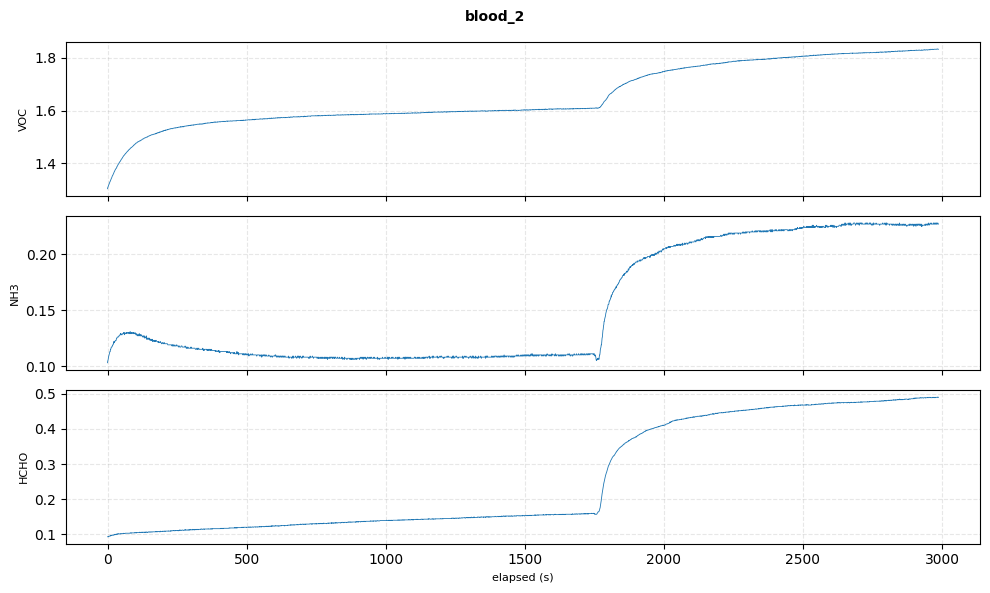

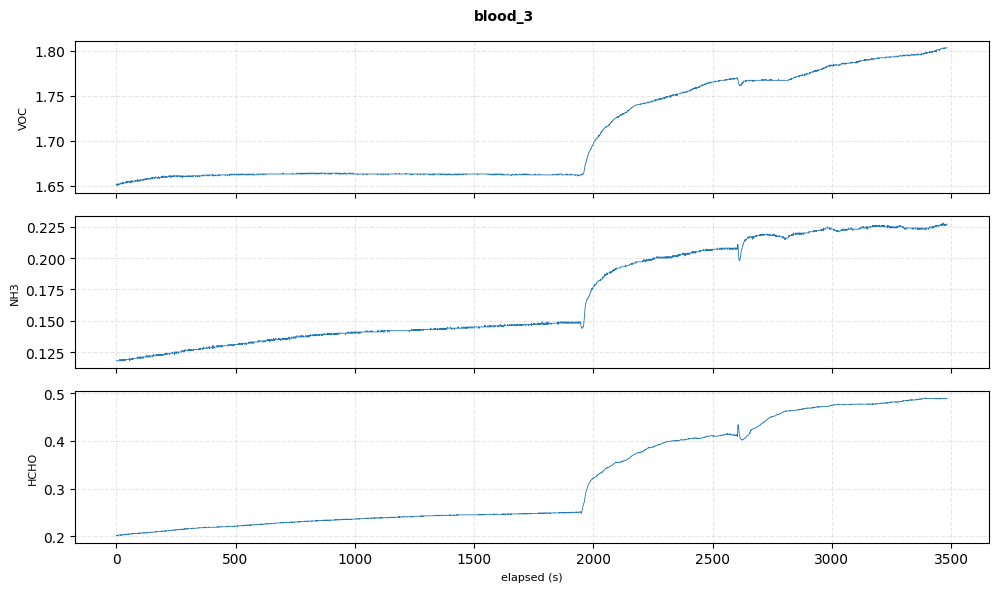

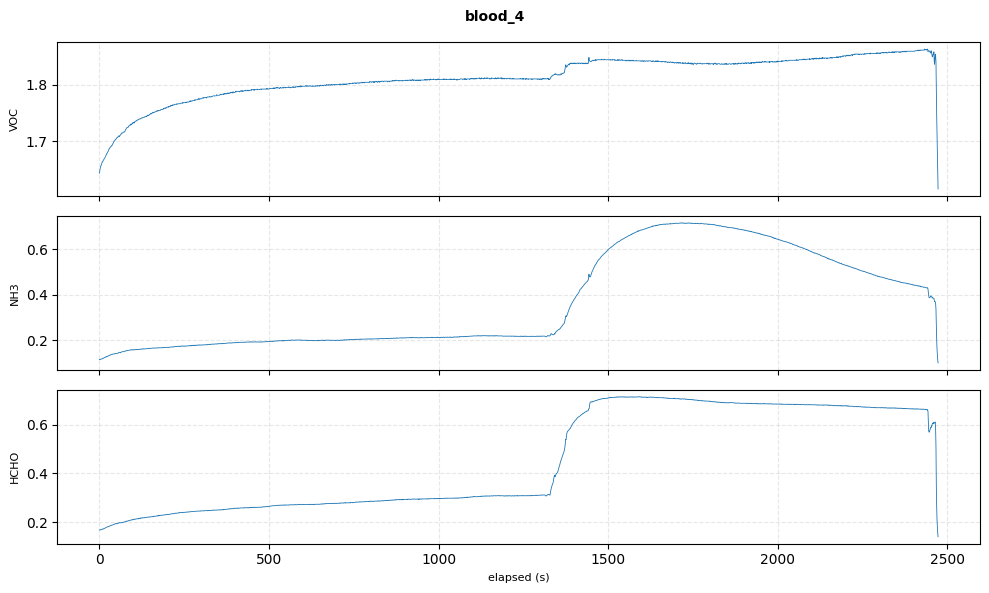

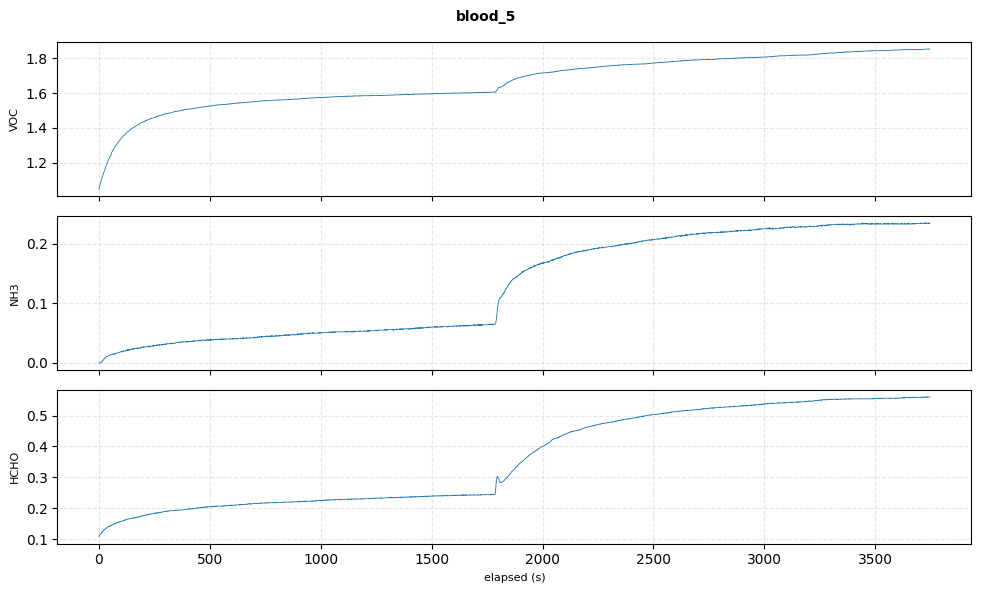

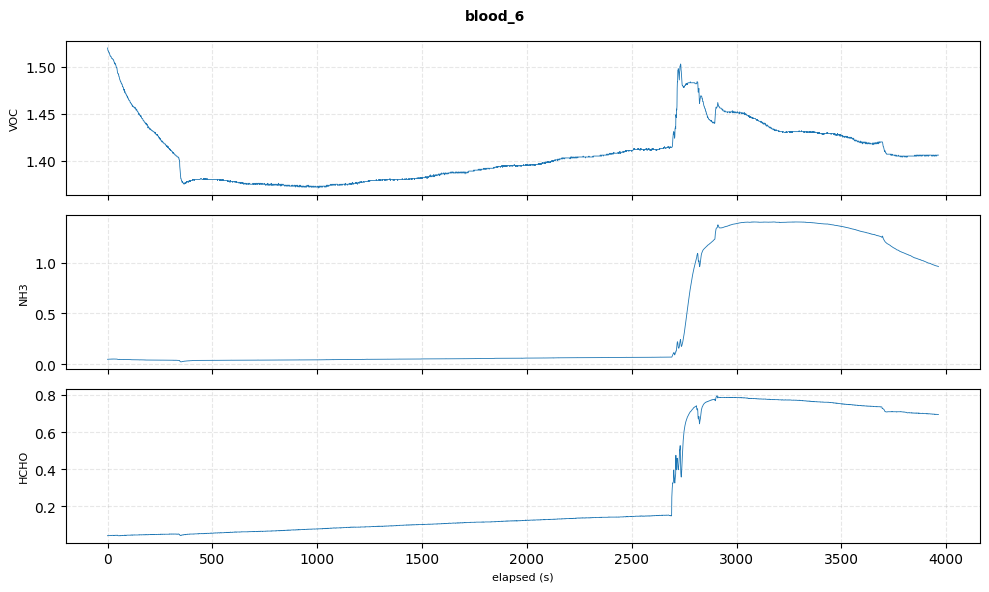

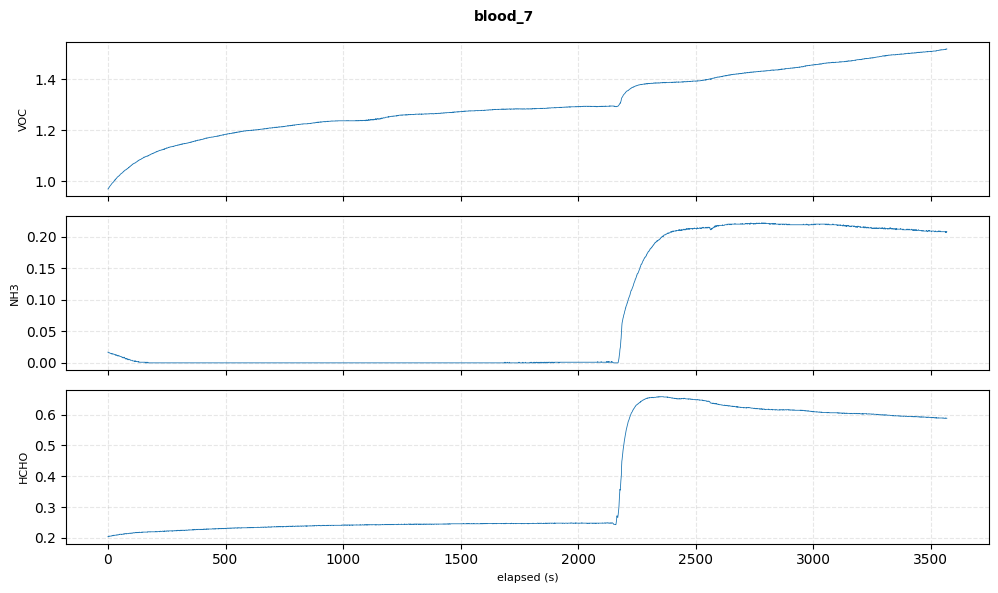

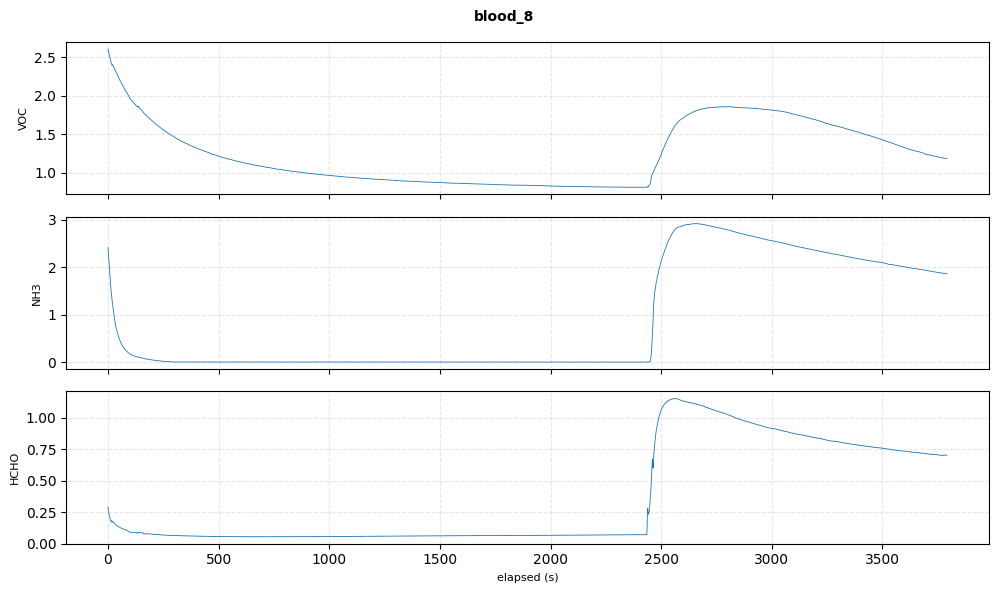

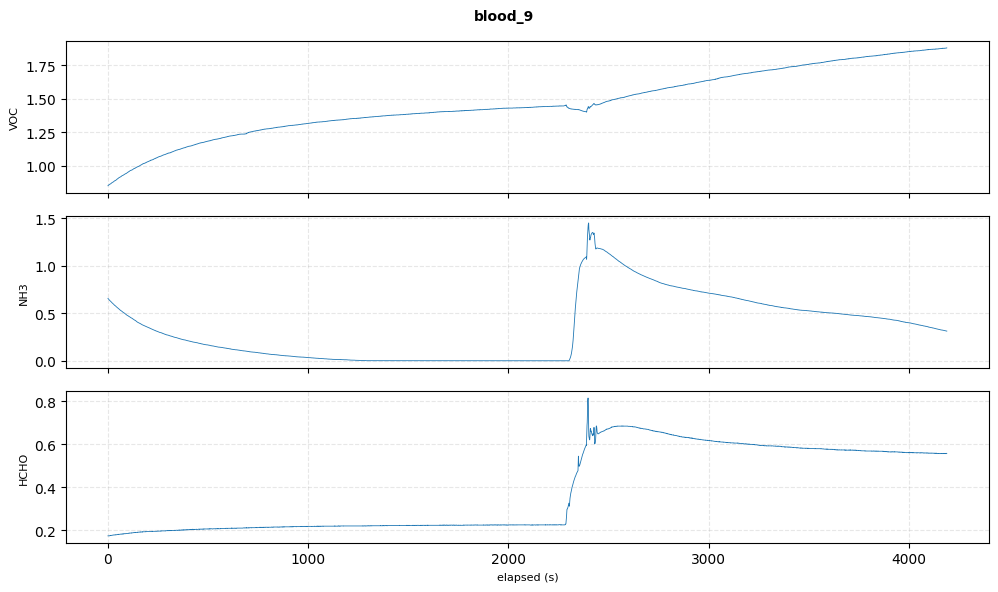

In [4]:
def plot_raw(name, df):
    fig, axes = plt.subplots(3, 1, figsize=(10, 6), sharex=True)
    fig.suptitle(name, fontsize=10, fontweight="bold")
    for ax, col in zip(axes, MEMS):
        ax.plot(df["elapsed_s"], df[col], linewidth=0.6)
        ax.set_ylabel(col.upper(), fontsize=8)
        ax.grid(True, alpha=0.3, linestyle="--")
    axes[-1].set_xlabel("elapsed (s)", fontsize=8)
    plt.tight_layout()
    plt.show()

all_raw = [
    ("sweat_1a", sweat_1a), ("sweat_1b", sweat_1b),
    ("sweat_2",  sweat_2),  ("sweat_3",  sweat_3),
    ("sweat_4",  sweat_4),  ("sweat_5",  sweat_5),
    ("sweat_6",  sweat_6),  ("sweat_7",  sweat_7),
    ("blood_0",  blood_0),  ("blood_1",  blood_1),
    ("blood_2",  blood_2),  ("blood_3",  blood_3),
    ("blood_4",  blood_4),  ("blood_5",  blood_5),
    ("blood_6",  blood_6),  ("blood_7",  blood_7),
    ("blood_8",  blood_8),  ("blood_9",  blood_9),
]

for name, df in all_raw:
    plot_raw(name, df)


## Filter

Each MEMS channel (VOC, NH3, HCHO) passes through the following pipeline in order:

1. **Zero interpolation** — isolated zero-voltage samples (stuck ADC reads) are replaced with `NaN` and linearly interpolated. Enabled per-channel via `interpolate_cols`.

2. **Artifact patch** — known bad time windows (e.g. connector disturbance, sensor reset) are replaced with `NaN` and linearly interpolated. Specified per-channel via `artifact_windows: {col: [(t_start, t_end), ...]}`.

3. **Spike detection** — samples where the absolute change from the previous sample exceeds `spike_thresh` (V/s) are flagged as `NaN` and linearly interpolated. Catches single-sample jumps not covered by artifact windows. A per-channel override is available via `spike_thresh_override`.

4. **Causal EMA smoothing** — exponential moving average with `span` (≈ seconds at 1 Hz). Uses `adjust=False` so it is fully causal (no future data). Per-channel span override available via `span_override`.

| Config key | Default | Description |
|---|---|---|
| `span` | 30 | EMA smoothing window (samples) |
| `span_override` | `{}` | Per-channel span override |
| `interpolate_cols` | `[]` | Channels to zero-interpolate |
| `artifact_windows` | `{}` | Manual bad-window patches per channel |
| `spike_thresh` | `0.05` | Max allowed V/s change before flagging as spike |
| `spike_thresh_override` | `{}` | Per-channel spike threshold override |


In [5]:
FILTER_CONFIG = {
    "SWEAT_1a": {
        "span": 30,
        "span_override": {},
        "interpolate_cols": [],
        "artifact_windows": {
            "voc":  [(2950, 3100)],
            "nh3":  [(2950, 3100)],
            "hcho": [(2950, 3100)],
        },
    },
    "SWEAT_1b": {
        "span": 30,
        "span_override": {"nh3": 80},
        "interpolate_cols": [],
        "artifact_windows": {
            "hcho": [(540, 570)],
        },
    },
    "SWEAT_2": {
        "span": 30,
        "span_override": {},
        "interpolate_cols": [],
        "artifact_windows": {},
    },
    "SWEAT_3": {
        "span": 30,
        "span_override": {},
        "interpolate_cols": [],
        "artifact_windows": {},
    },
    "SWEAT_4": {
        "span": 30,
        "span_override": {},
        "interpolate_cols": [],
        "artifact_windows": {},
    },
    "SWEAT_5": {
        "span": 30,
        "span_override": {},
        "interpolate_cols": [],
        "artifact_windows": {},
    },
    "SWEAT_6": {
        "span": 30,
        "span_override": {},
        "interpolate_cols": [],
        "artifact_windows": {},
    },
    "SWEAT_7": {
        "span": 30,
        "span_override": {},
        "interpolate_cols": [],
        "artifact_windows": {},
    },
    "BLOOD_0": {
        "span": 30,
        "span_override": {},
        "interpolate_cols": ["nh3"],
        "artifact_windows": {
            "nh3": [(1970, 2030)],
        },
    },
    "BLOOD_1": {
        "span": 30,
        "span_override": {},
        "interpolate_cols": [],
        "artifact_windows": {},
    },
    "BLOOD_2": {
        "span": 30,
        "span_override": {},
        "interpolate_cols": [],
        "artifact_windows": {},
    },
    "BLOOD_3": {
        "span": 30,
        "span_override": {},
        "interpolate_cols": [],
        "artifact_windows": {},
    },
    "BLOOD_4": {
        "span": 30,
        "span_override": {},
        "interpolate_cols": [],
        "artifact_windows": {},
    },
    "BLOOD_5": {
        "span": 30,
        "span_override": {},
        "interpolate_cols": [],
        "artifact_windows": {},
    },
    "BLOOD_6": {
        "span": 30,
        "span_override": {},
        "interpolate_cols": [],
        "artifact_windows": {},
    },
    "BLOOD_7": {
        "span": 30,
        "span_override": {},
        "interpolate_cols": [],
        "artifact_windows": {},
    },
    "BLOOD_8": {
        "span": 30,
        "span_override": {},
        "interpolate_cols": [],
        "artifact_windows": {},
    },
    "BLOOD_9": {
        "span": 30,
        "span_override": {},
        "interpolate_cols": [],
        "artifact_windows": {},
    },
}

def apply_filter(df: pd.DataFrame, config: dict) -> pd.DataFrame:
    out = df.copy()

    for col in MEMS:
        s = out[col].copy().astype(float)

        # 1. Zero interpolation
        if col in config.get("interpolate_cols", []):
            s[s == 0.0] = float("nan")
            s = s.interpolate(method="linear").ffill().bfill()

        # 2. Artifact patch
        for t0, t1 in config.get("artifact_windows", {}).get(col, []):
            mask = (out["elapsed_s"] >= t0) & (out["elapsed_s"] <= t1)
            s[mask] = float("nan")
            s = s.interpolate(method="linear").ffill().bfill()

        # 3. Causal EMA
        span: int = config.get("span_override", {}).get(col, config["span"])
        out[col] = s.ewm(span=span, adjust=False).mean()

    return out

filtered = {
    name: apply_filter(df, FILTER_CONFIG[name])
    for name, df in [
        ("SWEAT_1a", sweat_1a), ("SWEAT_1b", sweat_1b),
        ("SWEAT_2",  sweat_2),  ("SWEAT_3",  sweat_3),
        ("SWEAT_4",  sweat_4),  ("SWEAT_5",  sweat_5),
        ("SWEAT_6",  sweat_6),  ("SWEAT_7",  sweat_7),
        ("BLOOD_0",  blood_0),  ("BLOOD_1",  blood_1),
        ("BLOOD_2",  blood_2),  ("BLOOD_3",  blood_3),
        ("BLOOD_4",  blood_4),  ("BLOOD_5",  blood_5),
        ("BLOOD_6",  blood_6),  ("BLOOD_7",  blood_7),
        ("BLOOD_8",  blood_8),  ("BLOOD_9",  blood_9),
    ]
}

print(f"Filtered {len(filtered)} datasets: {list(filtered.keys())}")


Filtered 18 datasets: ['SWEAT_1a', 'SWEAT_1b', 'SWEAT_2', 'SWEAT_3', 'SWEAT_4', 'SWEAT_5', 'SWEAT_6', 'SWEAT_7', 'BLOOD_0', 'BLOOD_1', 'BLOOD_2', 'BLOOD_3', 'BLOOD_4', 'BLOOD_5', 'BLOOD_6', 'BLOOD_7', 'BLOOD_8', 'BLOOD_9']


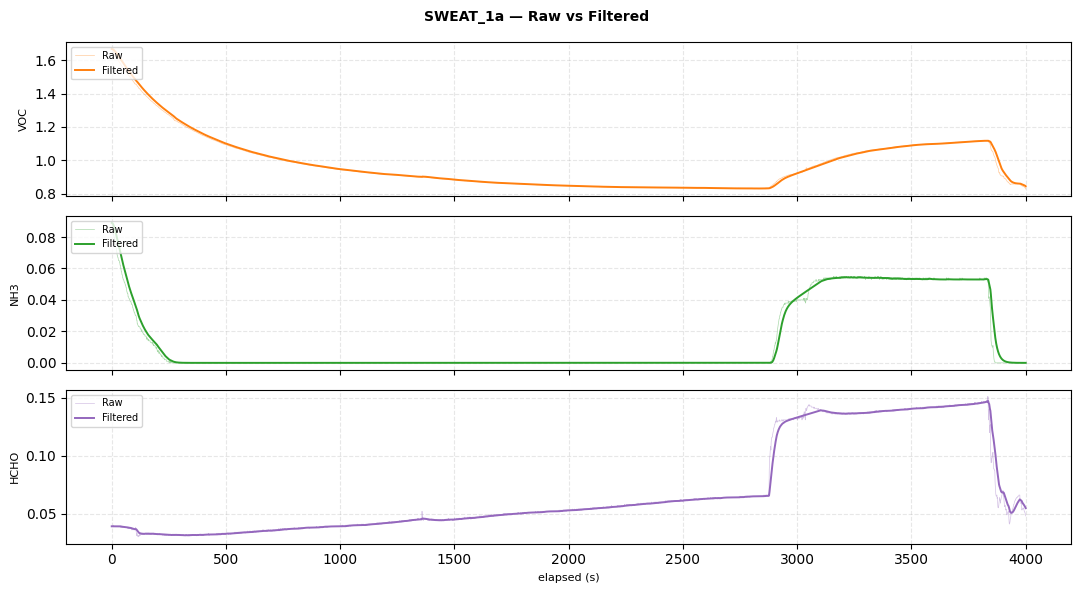

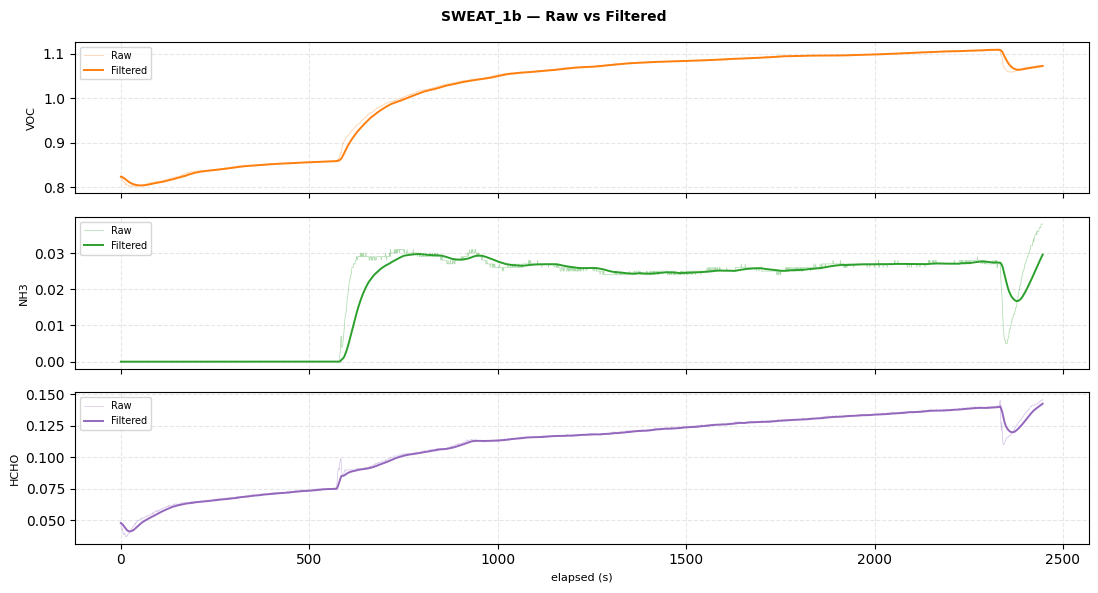

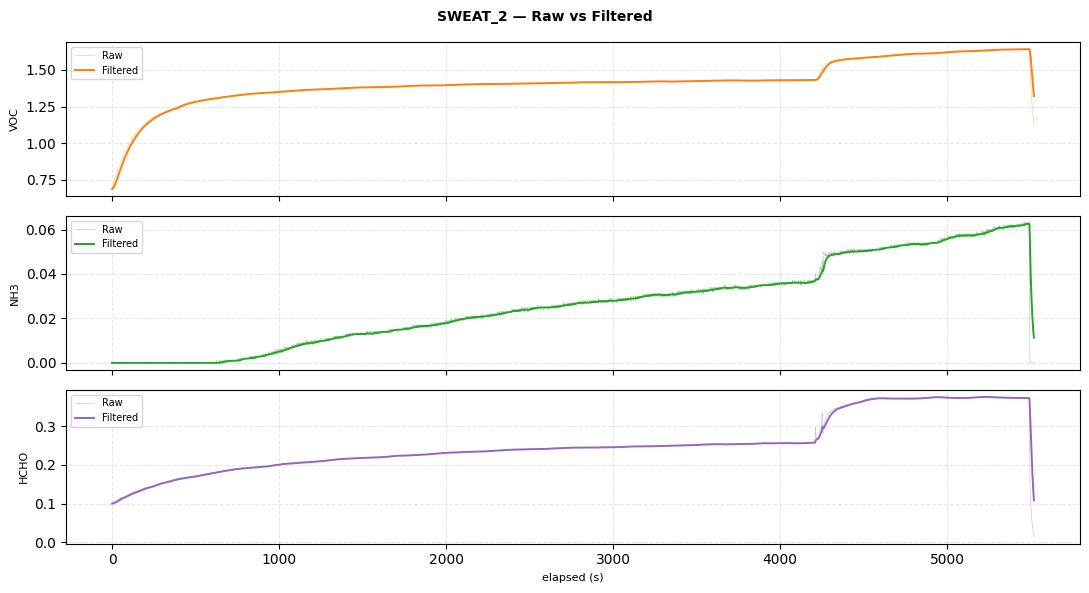

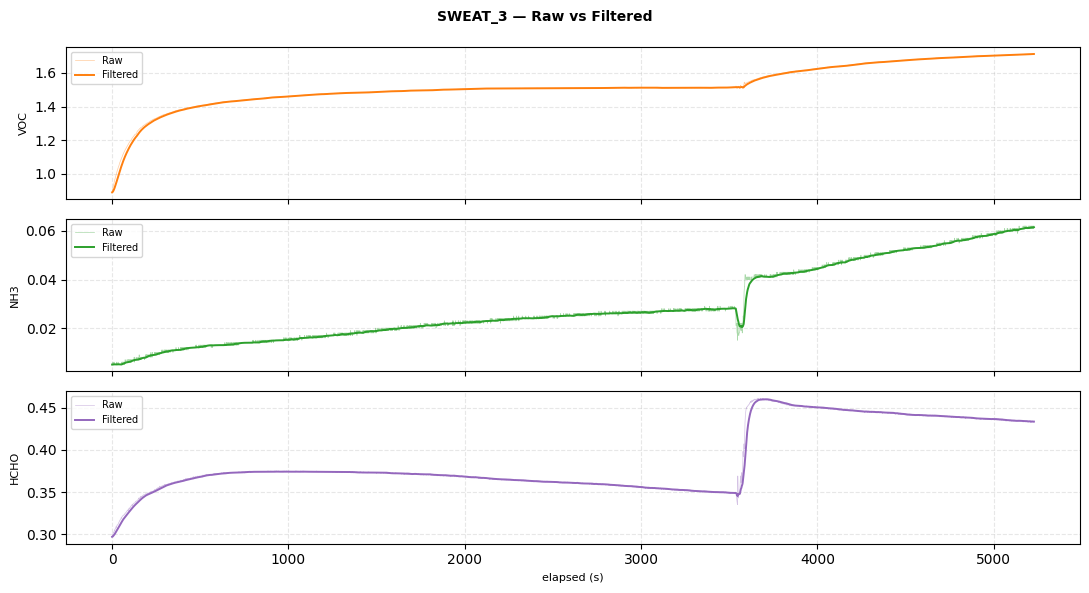

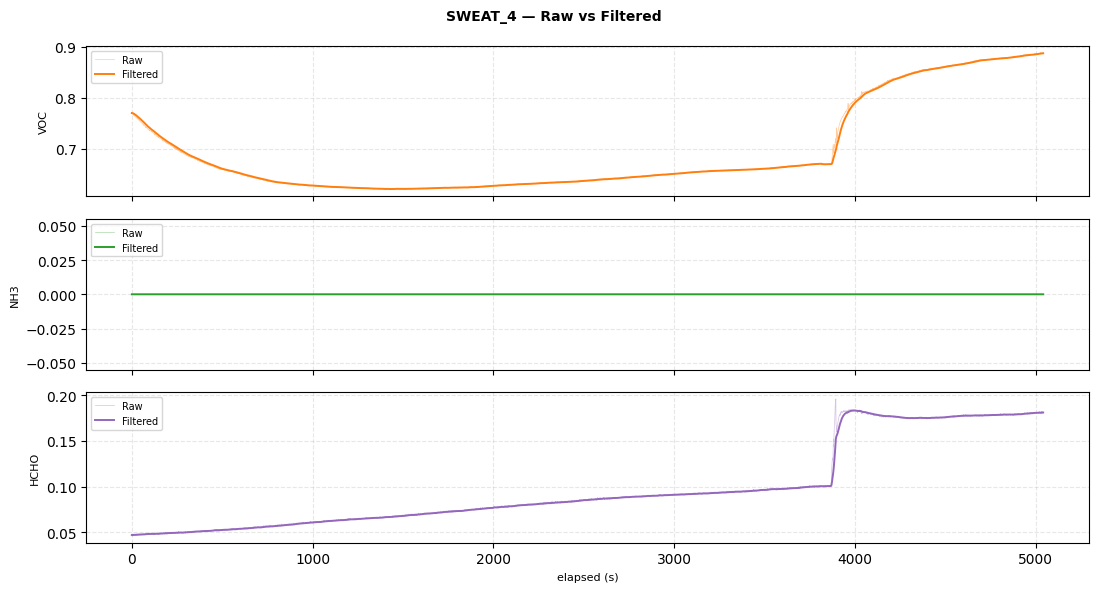

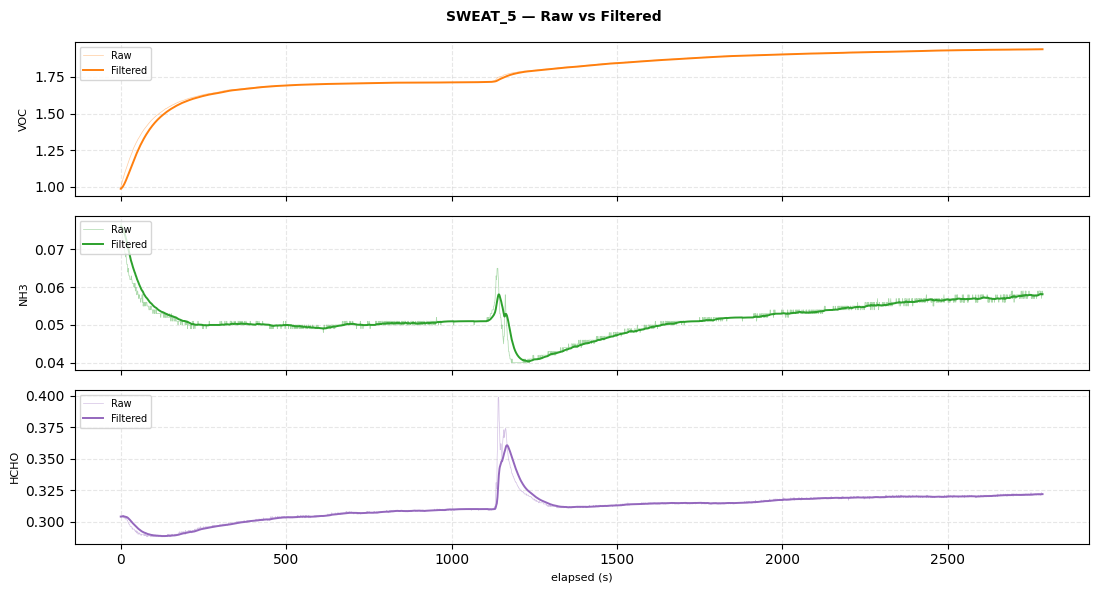

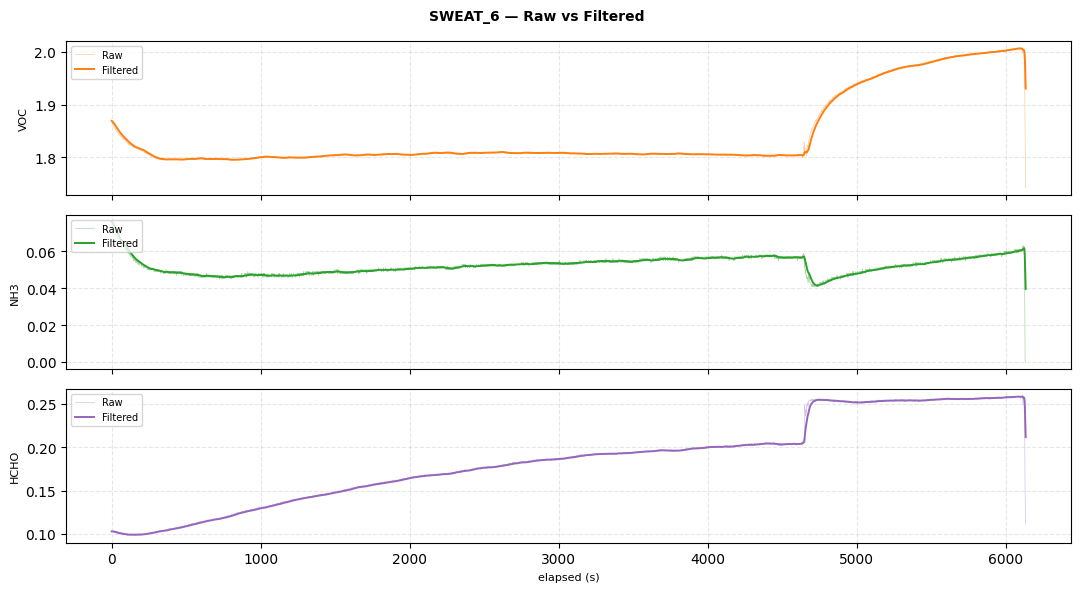

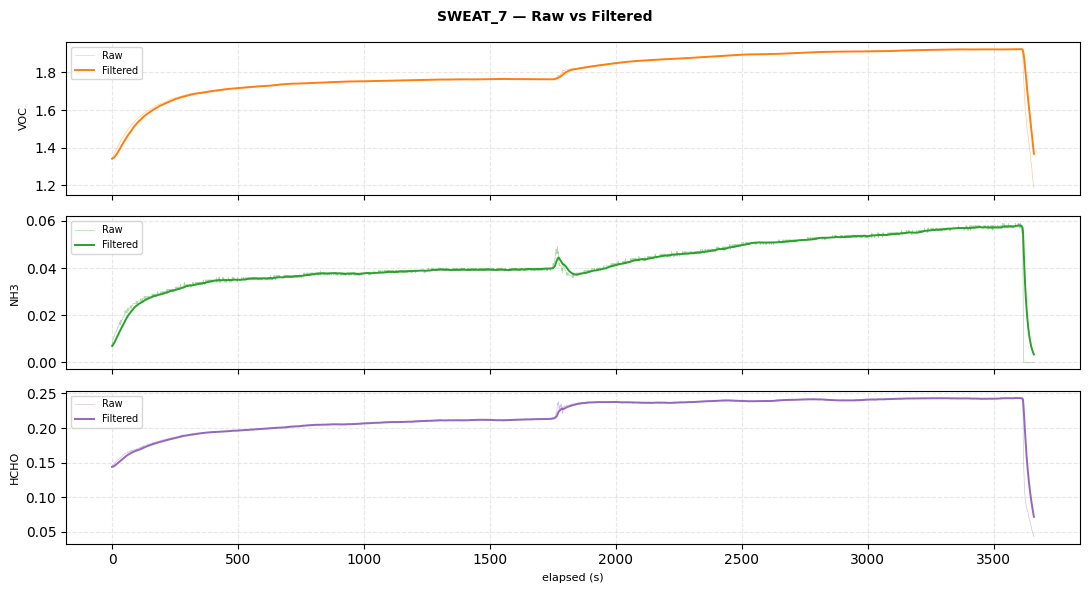

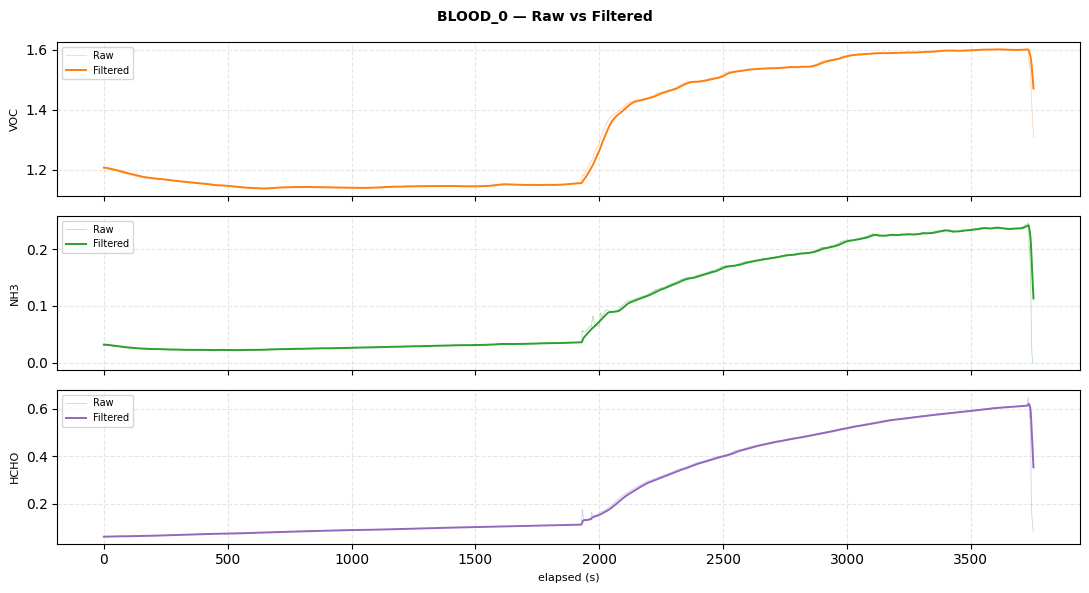

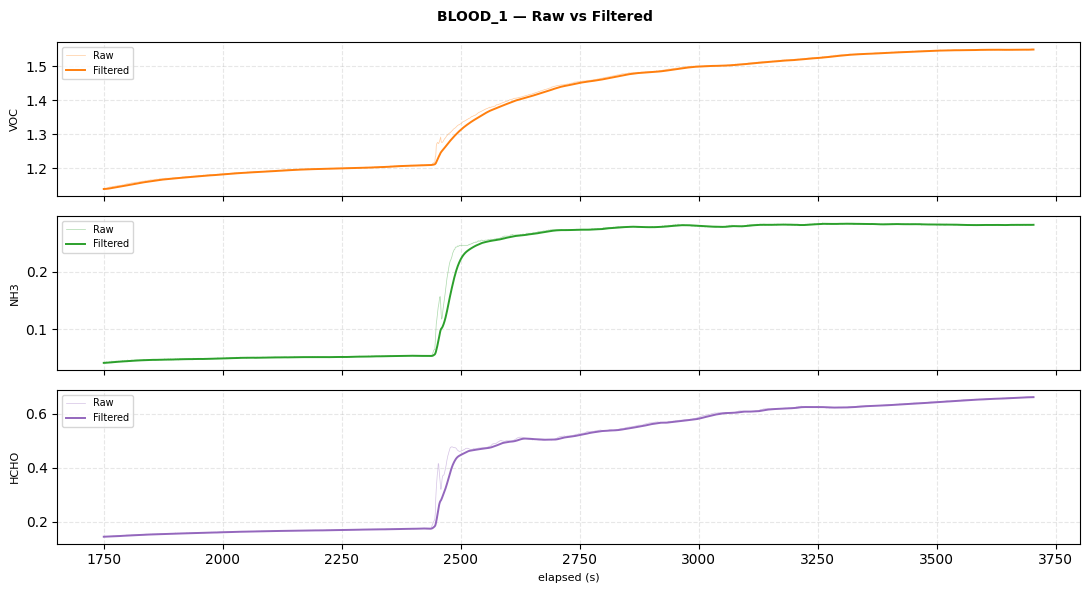

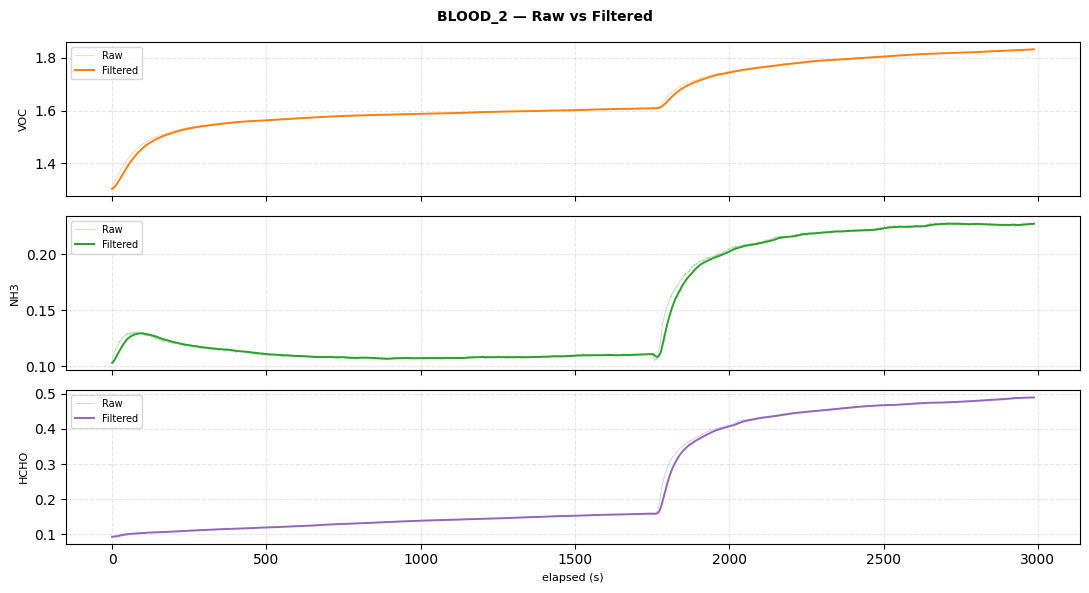

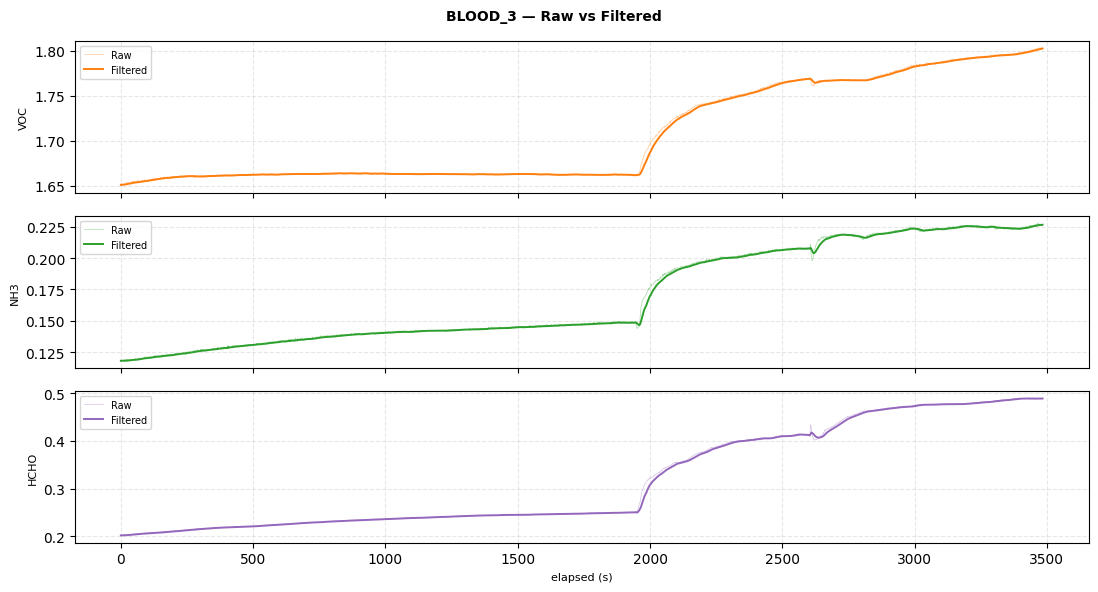

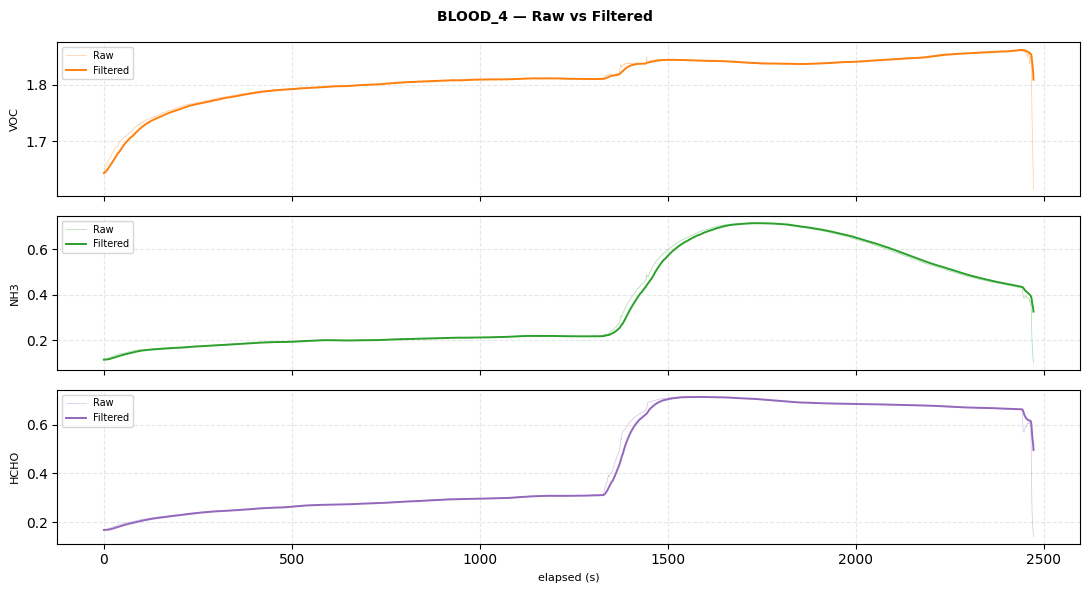

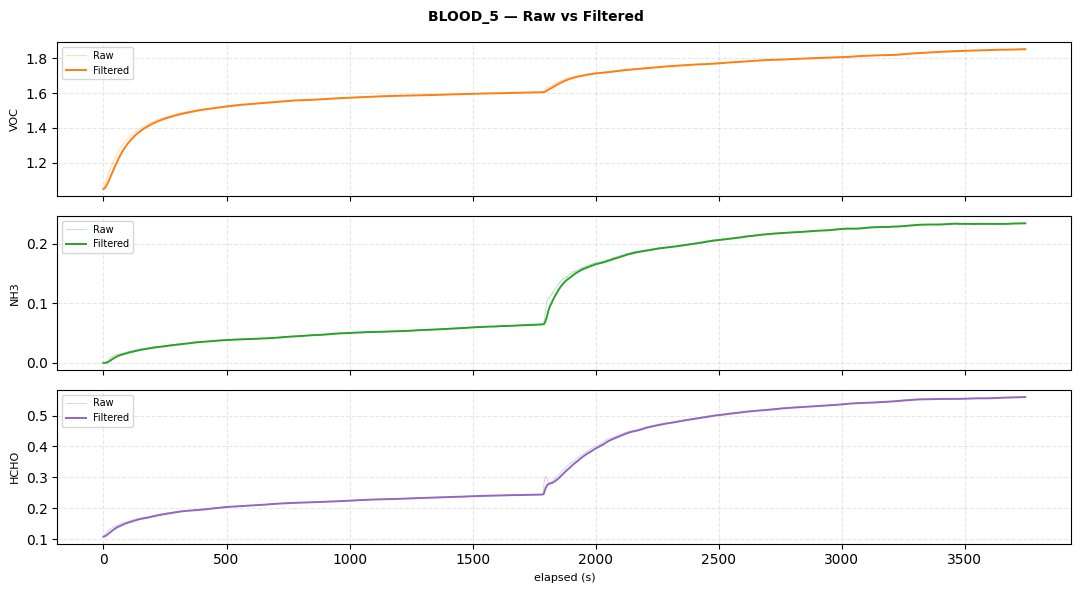

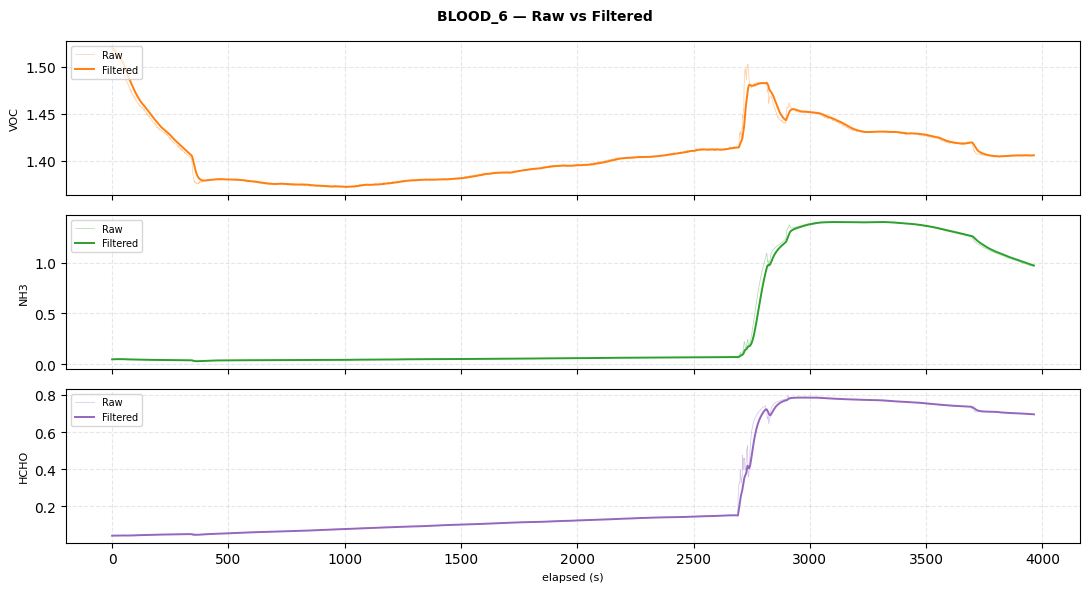

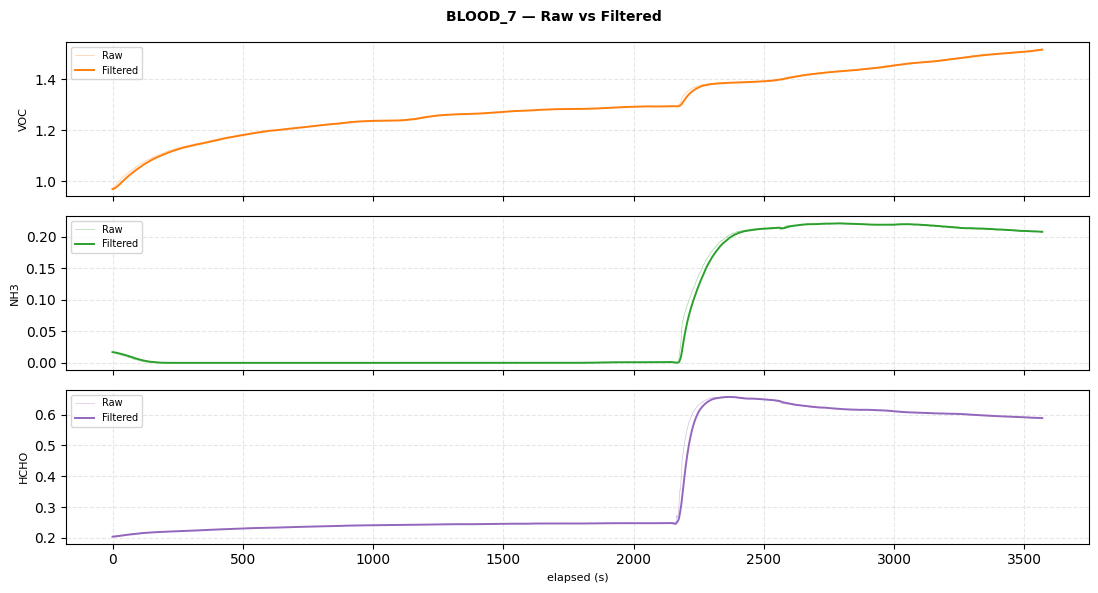

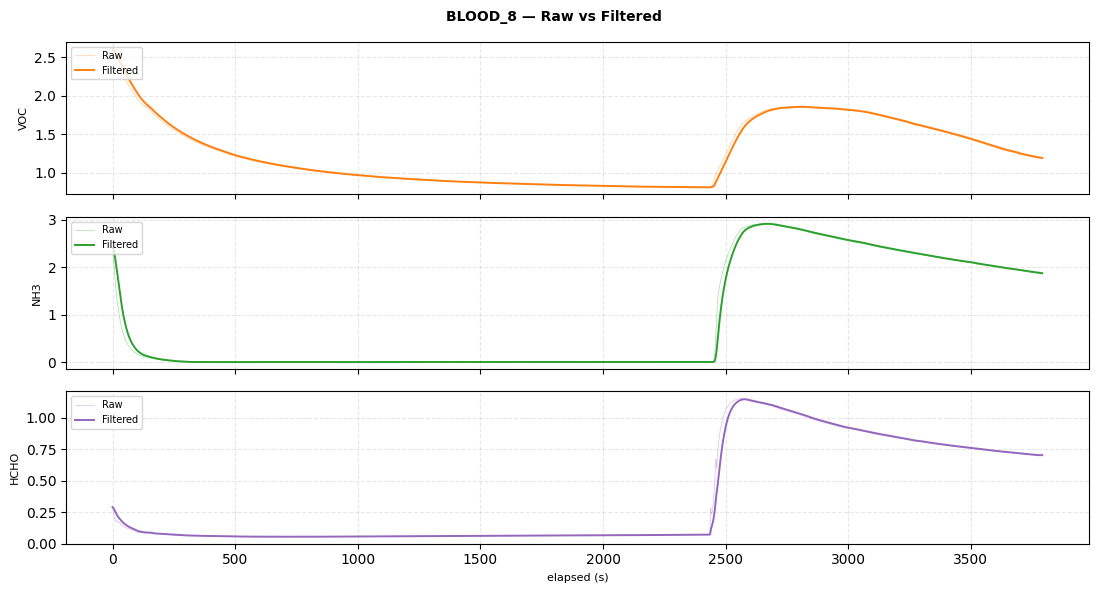

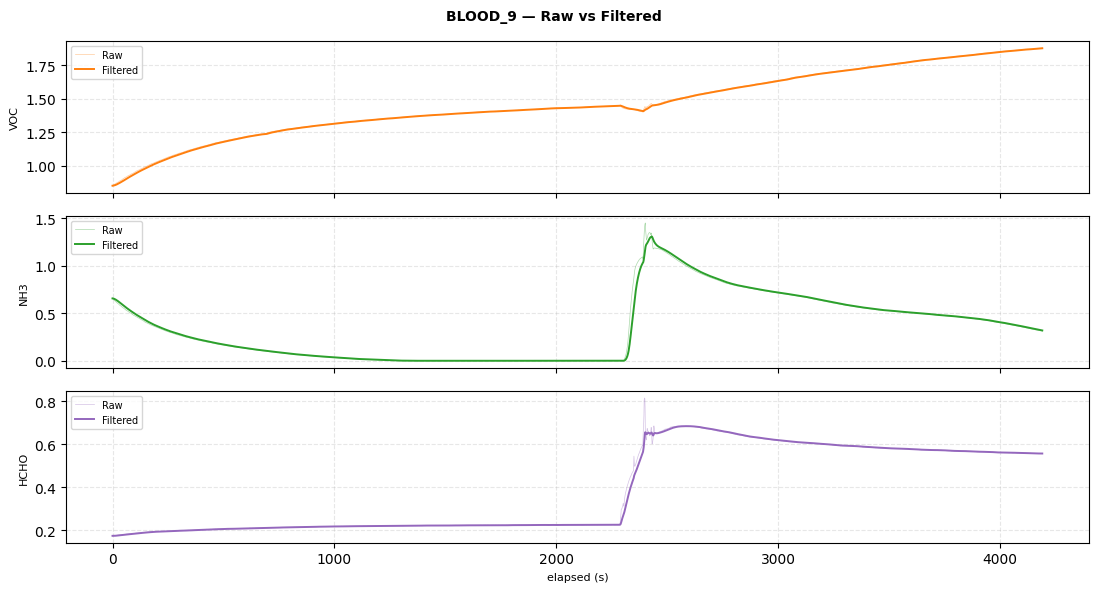

In [8]:
COLORS = {"voc": "tab:orange", "nh3": "tab:green", "hcho": "tab:purple"}

raw_map = {
    "SWEAT_1a": sweat_1a, "SWEAT_1b": sweat_1b,
    "SWEAT_2":  sweat_2,  "SWEAT_3":  sweat_3,
    "SWEAT_4":  sweat_4,  "SWEAT_5":  sweat_5,
    "SWEAT_6":  sweat_6,  "SWEAT_7":  sweat_7,
    "BLOOD_0":  blood_0,  "BLOOD_1":  blood_1,
    "BLOOD_2":  blood_2,  "BLOOD_3":  blood_3,
    "BLOOD_4":  blood_4,  "BLOOD_5":  blood_5,
    "BLOOD_6":  blood_6,  "BLOOD_7":  blood_7,
    "BLOOD_8":  blood_8,  "BLOOD_9":  blood_9,
}

for name, filt_df in filtered.items():
    raw_df = raw_map[name]
    fig, axes = plt.subplots(3, 1, figsize=(11, 6), sharex=True)
    fig.suptitle(f"{name} — Raw vs Filtered", fontsize=10, fontweight="bold")

    for ax, col in zip(axes, MEMS):
        color = COLORS[col]
        ax.plot(raw_df["elapsed_s"],  raw_df[col],  color=color, linewidth=0.5, alpha=0.4, label="Raw")
        ax.plot(filt_df["elapsed_s"], filt_df[col], color=color, linewidth=1.4, label="Filtered")
        ax.set_ylabel(col.upper(), fontsize=8)
        ax.legend(fontsize=7, loc="upper left")
        ax.grid(True, alpha=0.3, linestyle="--")

    axes[-1].set_xlabel("elapsed (s)", fontsize=8)
    plt.tight_layout()
    plt.show()


## Baseline and Sensor Drift Correction

Fits a linear trend to the pre-sample window of each channel and subtracts it from the full signal. Corrects for both the session baseline offset and slow in-session drift.

```
corrected(t) = filtered(t) − (a·t + b),   clipped at 0
```



SWEAT_1a  (baseline window: 1500–2800s,  1271 rows)
  channel      slope (V/s)   intercept (V)
  voc            -0.000036          0.9241
  nh3            -0.000000          0.0000
  hcho            0.000016          0.0218

SWEAT_1b  (baseline window: 0–570s,  557 rows)
  channel      slope (V/s)   intercept (V)
  voc             0.000104          0.8080
  nh3             0.000000         -0.0000
  hcho            0.000052          0.0500

BLOOD_0  (baseline window: 0–1900s,  1856 rows)
  channel      slope (V/s)   intercept (V)
  voc            -0.000015          1.1653
  nh3             0.000006          0.0221
  hcho            0.000027          0.0620

BLOOD_1  (baseline window: 1750–2440s,  674 rows)
  channel      slope (V/s)   intercept (V)
  voc             0.000091          0.9945
  nh3             0.000014          0.0200
  hcho            0.000041          0.0783


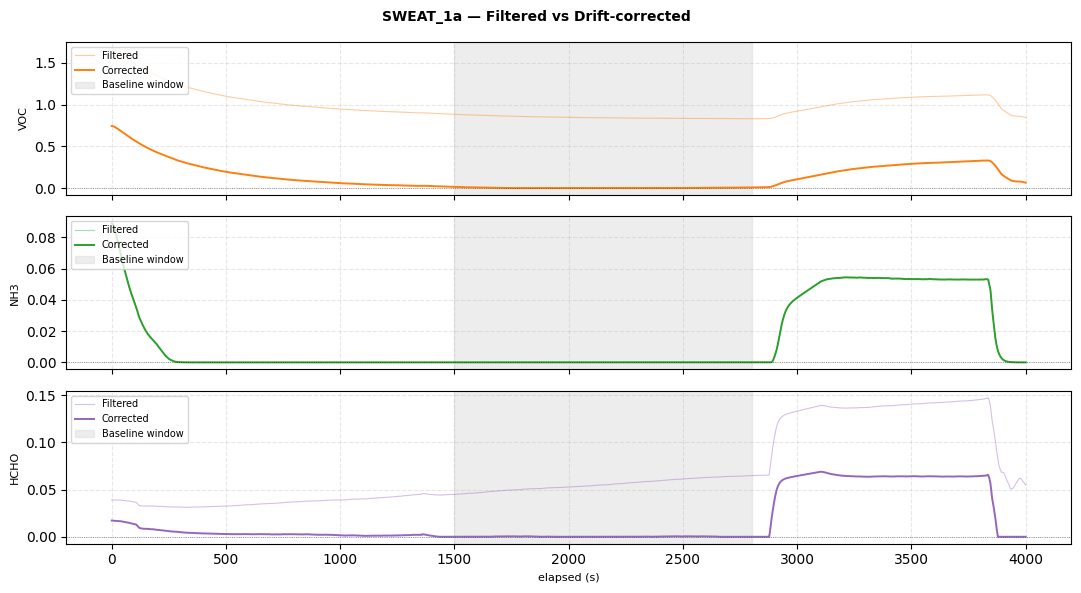

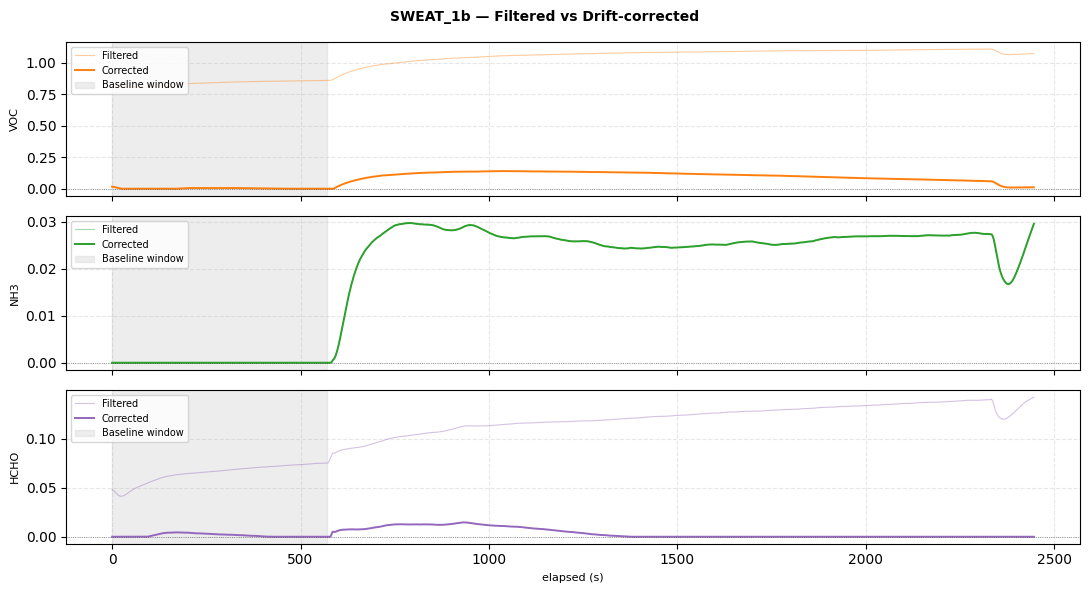

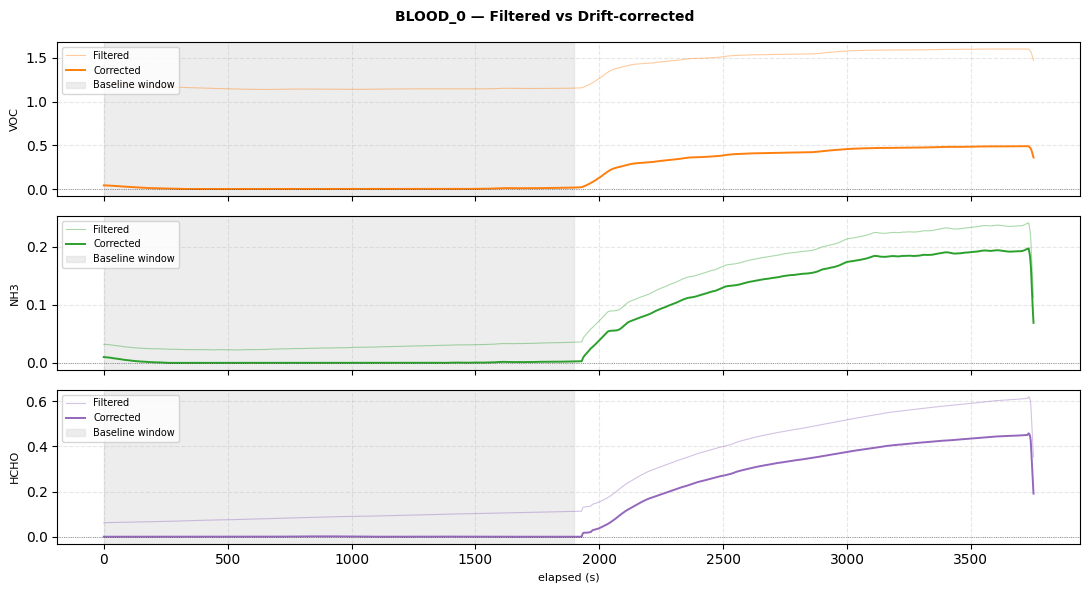

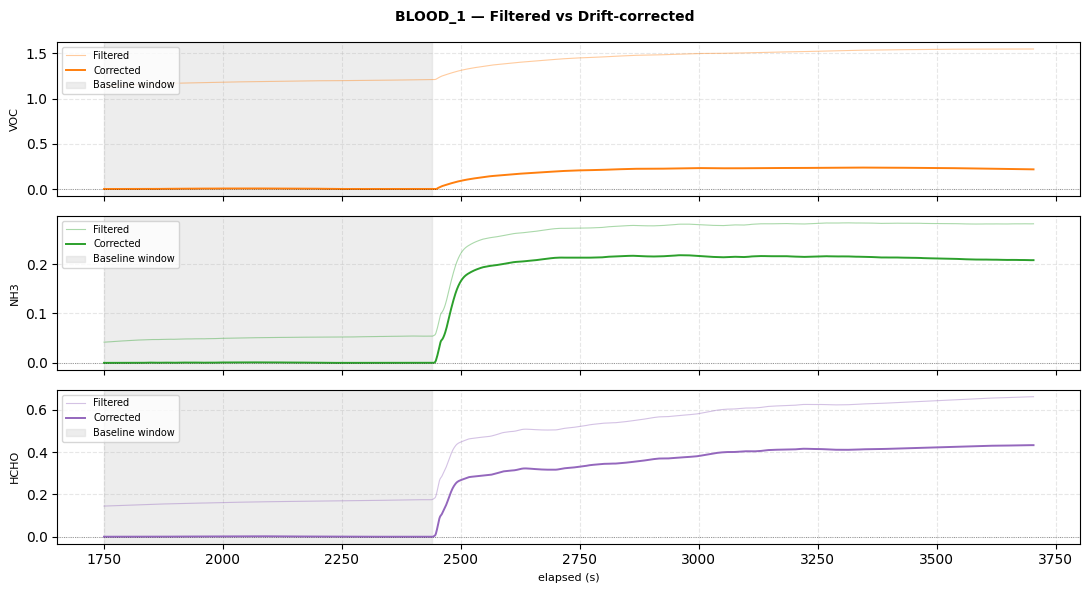

In [199]:
import numpy as np

# Pre-sample baseline windows (elapsed_s) per sub-dataset — rows before sample introduction
BASELINE_WINDOWS = {
    "SWEAT_1a": (1500, 2800),
    "SWEAT_1b": (0,    570),
    "BLOOD_0":  (0,    1900),
    "BLOOD_1":  (1750, 2440),
}

corrected = {}   # {name: DataFrame with drift-corrected MEMS channels}

for name, df in [
    ("SWEAT_1a", sweat_1a),
    ("SWEAT_1b", sweat_1b),
    ("BLOOD_0",  blood_0),
    ("BLOOD_1",  blood_1),
]:
    filt_df = filtered[name].copy()
    t0, t1  = BASELINE_WINDOWS[name]
    base_mask = (filt_df["elapsed_s"] >= t0) & (filt_df["elapsed_s"] <= t1)
    t_all = filt_df["elapsed_s"].values

    print(f"\n{name}  (baseline window: {t0}–{t1}s,  {base_mask.sum()} rows)")
    print(f"  {'channel':<8}  {'slope (V/s)':>14}  {'intercept (V)':>14}")

    for col in MEMS:
        t_base = filt_df.loc[base_mask, "elapsed_s"].values
        s_base = filt_df.loc[base_mask, col].values

        # Fit linear trend to baseline window
        a, b = np.polyfit(t_base, s_base, deg=1)
        trend = a * t_all + b

        filt_df[col] = (filt_df[col] - trend).clip(lower=0)
        print(f"  {col:<8}  {a:>14.6f}  {b:>14.4f}")

    corrected[name] = filt_df

# ── Visualize corrected vs filtered ──────────────────────────────────────────
for name in corrected:
    raw_filt = filtered[name]
    corr     = corrected[name]

    fig, axes = plt.subplots(3, 1, figsize=(11, 6), sharex=True)
    fig.suptitle(f"{name} — Filtered vs Drift-corrected", fontsize=10, fontweight="bold")

    for ax, col in zip(axes, MEMS):
        color = COLORS[col]
        ax.plot(raw_filt["elapsed_s"], raw_filt[col], color=color,
                linewidth=0.8, alpha=0.4, label="Filtered")
        ax.plot(corr["elapsed_s"],     corr[col],     color=color,
                linewidth=1.4, label="Corrected")
        t0, t1 = BASELINE_WINDOWS[name]
        ax.axvspan(t0, t1, color="lightgrey", alpha=0.4, label="Baseline window")
        ax.axhline(0, color="black", linewidth=0.6, linestyle=":", alpha=0.5)
        ax.set_ylabel(col.upper(), fontsize=8)
        ax.legend(fontsize=7, loc="upper left")
        ax.grid(True, alpha=0.3, linestyle="--")

    axes[-1].set_xlabel("elapsed (s)", fontsize=8)
    plt.tight_layout()
    plt.show()


## Export Data

In [200]:
import os, pickle

os.makedirs("processed", exist_ok=True)

# Export filtered MEMS channels + ENV (temp_C, rh_pct) per sub-dataset.
# filtered[key] is a full copy of the raw DataFrame with MEMS cols EMA-filtered.
export_map = {
    "SWEAT_1a": "mems_sweat_1a",
    "SWEAT_1b": "mems_sweat_1b",
    "BLOOD_0":  "mems_blood_0",
    "BLOOD_1":  "mems_blood_1",
}

for key, fname in export_map.items():
    cols = ["elapsed_s"] + MEMS + ["temp_C", "rh_pct"]
    df   = corrected[key][cols].copy()
    path = f"processed/{fname}.pkl"
    df.to_pickle(path)
    print(f"Saved {path}  ({len(df)} rows)")


Saved processed/mems_sweat_1a.pkl  (3909 rows)
Saved processed/mems_sweat_1b.pkl  (2390 rows)
Saved processed/mems_blood_0.pkl  (3666 rows)
Saved processed/mems_blood_1.pkl  (1908 rows)


## Validate Test

In [201]:
BLOOD_VALIDATE_1 = "../20260331-experiment/1.5blood_1.csv"

## Validation — Apply Full Pipeline to BLOOD_VALIDATE_1

Load the held-out validation recording and apply the same pipeline used for training data:
1. EMA filter (span=30, with NH3 isolated-zero interpolation)
2. Linear baseline drift correction — window: **2000–2400 s** (warm-up: 0–2500 s)
3. Trim: discard everything before **3500 s**

In [1]:
# ── Load (full recording — baseline correction needs pre-3500s data) ──────────
blood_val = load(BLOOD_VALIDATE_1)
print(f"Loaded BLOOD_VALIDATE_1: {len(blood_val)} rows")

# ── EMA filter ────────────────────────────────────────────────────────────────
BLOOD_VAL_FILTER_CONFIG = {
    "span": 30,
    "span_override": {},
    "interpolate_cols": ["nh3"],
    "artifact_windows": {},
}
blood_val_filtered = apply_filter(blood_val, BLOOD_VAL_FILTER_CONFIG)

# ── Baseline drift correction ─────────────────────────────────────────────────
# Warm-up: 0–2500 s.  Baseline window: 2000–2400 s (stable pre-sample region).
BASELINE_WINDOWS["BLOOD_VAL"] = (2000, 2400)

t0_v, t1_v = BASELINE_WINDOWS["BLOOD_VAL"]
base_mask_v = (blood_val_filtered["elapsed_s"] >= t0_v) & (blood_val_filtered["elapsed_s"] <= t1_v)
t_all_v     = blood_val_filtered["elapsed_s"].values

blood_val_corrected = blood_val_filtered.copy()
print(f"\nBaseline window: {t0_v}–{t1_v} s  ({base_mask_v.sum()} rows)")
print(f"  {'channel':<8}  {'slope (V/s)':>14}  {'intercept (V)':>14}")

for col in MEMS:
    t_base = blood_val_filtered.loc[base_mask_v, "elapsed_s"].values
    s_base = blood_val_filtered.loc[base_mask_v, col].values
    a, b   = np.polyfit(t_base, s_base, deg=1)
    trend  = a * t_all_v + b
    blood_val_corrected[col] = (blood_val_filtered[col] - trend).clip(lower=0)
    print(f"  {col:<8}  {a:>14.6f}  {b:>14.4f}")

# ── Trim: discard warm-up, keep ≥ 3500 s ─────────────────────────────────────
trim_mask           = blood_val_corrected["elapsed_s"] >= 3500
blood_val_trimmed   = blood_val_corrected[trim_mask].reset_index(drop=True)
blood_val_raw_trim  = blood_val[trim_mask].reset_index(drop=True)
print(f"\nTrimmed output: {len(blood_val_trimmed)} rows  "
      f"({blood_val_trimmed['elapsed_s'].iloc[0]:.0f}–{blood_val_trimmed['elapsed_s'].iloc[-1]:.0f} s)")

NameError: name 'load' is not defined

In [2]:
# ── Before / After plot — Raw vs Drift-corrected ──────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=True)
fig.suptitle("BLOOD_VALIDATE_1 — Raw vs Drift-corrected",
             fontsize=11, fontweight="bold")

for ax, col in zip(axes, MEMS):
    color = COLORS[col]
    t     = blood_val["elapsed_s"]
    ax.plot(t, blood_val[col],           color=color, linewidth=0.5, alpha=0.35, label="Raw")
    ax.plot(t, blood_val_corrected[col], color=color, linewidth=1.4,             label="Drift-corrected")
    ax.axvspan(t0_v, t1_v, color="lightgrey", alpha=0.5, label=f"Baseline ({t0_v}–{t1_v} s)")
    ax.axhline(0, color="black", linewidth=0.6, linestyle=":", alpha=0.4)
    ax.set_ylabel(col.upper(), fontsize=8)
    ax.legend(fontsize=7, loc="upper left")
    ax.grid(True, alpha=0.3, linestyle="--")

axes[-1].set_xlabel("elapsed (s)", fontsize=8)
plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined